In [2]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
import platform
import matplotlib.ticker as mtick

In [4]:
# 中证全指相关数据
zzqz = pd.read_excel('data/zzqz.xlsx',sheet_name='Sheet1',skiprows=[0,1,2],parse_dates=['Date'],index_col='Date')
# 行业行情数据
inds_price = pd.read_excel('data/行情数据-PMS时点.xlsx',skiprows=[0,1,3],sheet_name='Sheet2',parse_dates=['日期'],index_col='日期')
inds_price.drop(['中证全指','综合(中信)','综合金融(中信)'],axis=1,inplace=True)
# 北向资金数据
bxzj = pd.read_excel('data/北向资金净流入数据.xlsx',skiprows=list(range(5)),names=['tradt','每日净流入额'],parse_dates=['tradt'],index_col='tradt')
# CPI_PPI数据
cpi_ppi_pbldt = pd.read_excel('data/CPI-PPI-pbldt.xlsx',sheet_name='Sheet1',parse_dates=['publishDate'],index_col='publishDate').drop('periodDate',axis=1)

In [6]:
# 计算ATR指标
zzqz['prev_close'] = zzqz['close'].shift(1)
zzqz['tr'] = zzqz.apply(
    lambda x: max(
        (x['high']-x['low'])/x['prev_close'],
        np.abs(x['high']-x['prev_close'])/x['prev_close'],
        np.abs(x['prev_close']-x['low'])/x['prev_close']
    ),
    axis=1
)
zzqz['atr_60'] = zzqz['tr'].rolling(60).mean()
zzqz['ret_1day'] = zzqz['close'].pct_change()

# 反弹动量

In [9]:
def cal_rebound_signal(zzqz,inds_price,D=0.05,U=0.005,sensitivity_test=False):
    """
    参数：
         zzqz: 中证全指股价数据
         inds_price: 中信一级行业股价走势（不含'综合','综合金融'）
         D: 阈值参数——初始下跌阈值
         U: 阈值参数——初始上涨阈值
         sensitivity_test: 敏感性检验参数，True表示此时是在进行对 U 和 D 的参数敏感性检验。
                           该参数作用是进行敏感性检验的时候，遍历每个日期时下跌阈值和上涨阈值
                           就不根据ATR_60调整，而是全程固定为D，U。
    返回值：
          （1）记录反弹信号触发日期，数据框格式（n行1列），行索引为2013年以来的所有交易日，
              列名为‘反弹’，值为0-1格式，1表示该交易日信号触发
          （2）反弹动量因子：数据框格式（m行28列），行索引为所有信号触发日，列为28个中信
              一级行业名，每行值都是Rank之后的值（1-28）
    """
    # 定义函数，根据ATR指标计算 U 和 D 的调整值
    def get_dynamic_threshold(atr_value, base_down=D, base_up=U):
        if atr_value < 0.01:
            adj_factor = np.sqrt(atr_value / 0.01)
            return base_down * adj_factor, base_up * adj_factor
        elif atr_value > 0.02:
            adj_factor = np.sqrt(atr_value / 0.02)
            return base_down * adj_factor, base_up * adj_factor
        else:
            return base_down, base_up
            
    # 寻找反弹信号触发日期
    rebound_dates = []
    for i in range(2,len(zzqz)):
        current_date = zzqz.index[i]
        current_ret = zzqz['ret_1day'].iloc[i]
        atr_value = zzqz['atr_60'].iloc[i]
        
        # 做敏感性测试时固定阈值，否则正常采取动态阈值
        if sensitivity_test:
            down_threshold, up_threshold = D, U
        else:
            down_threshold, up_threshold = get_dynamic_threshold(atr_value)       
            
        # 如果T日涨跌幅超过U
        if current_ret > up_threshold:
            # 向前寻找最长区间M
            m_start = i-1
            for j in range(i-1,-1,-1):
                daily_ret = zzqz['ret_1day'].iloc[j]
                if daily_ret > up_threshold:
                    m_start = j
                    break
                
            # 在区间M内寻找最高点和最低点
            m_prices = zzqz['close'].iloc[m_start:i]
            if len(m_prices) == 0:
                continue
            
            close_high = m_prices.max()    # 最高点
            high_date = m_prices.idxmax()    # 最高点日期
            close_low = m_prices.min()    # 最后一个最低点
            low_date = m_prices.idxmin()     # 最低点日期
    
            # 检查条件：最高点在最低点之前，且间隔>2个交易日
            if (m_prices.index.get_loc(low_date) - m_prices.index.get_loc(high_date)) > 2:
                drawdown = 1 - (close_low/close_high)
                # 如果下跌幅度大于 D
                if drawdown > down_threshold:
                    # 记录触发日期
                    rebound_dates.append(current_date)
                    
    # 最终反弹信号（截面排序）
    rebound_signals = inds_price.pct_change().apply(lambda col: col - col.rolling(20).mean()).loc[rebound_dates].rank(axis=1)
    rebound_signals = rebound_signals.loc[rebound_signals.index >= pd.to_datetime('2013-01-01')]
    rebound_signals.index.name = 'tradt'
    
    # 获取2013年以来交易日期，其值为0，1格式，如果值为1则表示有信号触发
    is_rebound_dates = pd.DataFrame(index=inds_price.index[inds_price.index>=pd.to_datetime('2013-01-01')])
    is_rebound_dates['反弹'] = 0
    is_rebound_dates.index.name = 'tradt'
    is_rebound_dates.loc[[date for date in rebound_dates if date >= pd.to_datetime('2013-01-01')]] = 1
    
    return is_rebound_dates, rebound_signals

In [11]:
is_rebound_dates, rebound_signals = cal_rebound_signal(zzqz,inds_price)

# 切换动量

In [14]:
def cal_switch_signal(zzqz,inds_price,high_inds_down = 3,sensitivity_D = None):
    """
    参数：
         zzqz: 中证全指股价数据
         inds_price: 中信一级行业股价走势（不含'综合','综合金融'）
         high_inds_down: 阈值参数——新高行业数量减少个数阈值
         sensitivity_D: 阈值参数——当日下跌幅度阈值，该参数默认为None，在进行参数敏感性检验时才设置它
    返回值：
          （1）记录切换信号触发日期，数据框格式（n行1列），行索引为2013年以来的所有交易日，
              列名为‘切换’，值为0-1格式，1表示该交易日信号触发
          （2）切换动量因子：数据框格式（m行28列），行索引为所有信号触发日，列为28个中信
              一级行业名，每行值都是Rank之后的值（1-28）
    """   
    # 计算每周创52周新高的行业数量
    high_counts = pd.DataFrame(index=inds_price.index,columns=['count','prev_count'])
    # 计算每个行业是否创52周新高（252个交易日）
    is_new_high = inds_price.rolling(252).apply(
        lambda x: x[-1] > x[:-1].max(),raw=True
    )
    # 统计每日新高行业数量
    high_counts['count'] = is_new_high.sum(axis=1)
    high_counts['prev_count'] = high_counts['count'].shift(1)
    
    # 切换条件：
    #（1）T 日创出 52 周新高的行业数量较 T-1 日创 52 周新高行业数量减少 high_ind_down 以上(包含 high_ind_down )；
    #（2）T 日中证全指跌幅超过（ ATR60 / sensitivity_D ）
    
    # 做敏感性测试时固定阈值，否则正常采取动态阈值
    if sensitivity_D:
        switch_condition = (high_counts['count'] - high_counts['prev_count'] <= -high_inds_down) & (zzqz['ret_1day'] < -sensitivity_D)
    else:
        switch_condition = (high_counts['count'] - high_counts['prev_count'] <= -high_inds_down) & (zzqz['ret_1day'] < -zzqz['atr_60'])
        
    # 切换日期
    switch_dates = switch_condition[switch_condition].index
    
    # 最终切换信号（截面排序）
    switch_signals = inds_price.pct_change().rank(axis=1).loc[switch_dates]
    switch_signals = switch_signals.loc[switch_signals.index >= pd.to_datetime('2013-01-01')]
    switch_signals.index.name = 'tradt'
    
    # 获取2013年以来交易日期，其值为0，1格式，如果值为1则表示有信号触发
    is_switch_dates = pd.DataFrame(index=inds_price.index[inds_price.index>=pd.to_datetime('2013-01-01')])
    is_switch_dates['切换'] = 0
    is_switch_dates.index.name = 'tradt'
    is_switch_dates.loc[[date for date in switch_dates if date >= pd.to_datetime('2013-01-01')]] = 1
    return is_switch_dates, switch_signals

In [16]:
is_switch_dates, switch_signals = cal_switch_signal(zzqz,inds_price)

# 突破动量

In [19]:
def cal_breakthrough_signal(zzqz,inds_price,C=0.01,B=0.01):
    """
    参数：
         zzqz: 中证全指股价数据
         inds_price: 中信一级行业股价走势（不含'综合','综合金融'）
         C: 阈值参数——收缩幅度阈值
         B: 阈值参数——突破幅度阈值
    返回值：
          （1）记录突破信号触发日期，数据框格式（n行1列），行索引为2013年以来的所有交易日，
              列名为‘突破’，值为0-1格式，1表示该交易日信号触发
          （2）突破动量因子：数据框格式（m行28列），行索引为所有信号触发日，列为28个中信
              一级行业名，每行值都是Rank之后的值（1-28）
    """   
    # 先计算滚动5日通道宽度
    zzqz['通道宽度'] = zzqz.rolling(5)['high'].max() - zzqz.rolling(5)['low'].min()
    
    # 寻找突破触发日期
    breakthrough_dates = []
    
    for i in range(6,len(zzqz)):
        current_date = zzqz.index[i]
        current_ret = zzqz['ret_1day'].iloc[i]
        # 条件1: T日涨跌幅大于B
        if current_ret <= B:
            continue
        # 条件2: 过去5日每日涨跌幅绝对值小于C
        prev_5days_ret = zzqz['ret_1day'].iloc[i-5:i]
        if (prev_5days_ret.abs() >= C).any():
            continue
        # 条件3:T-1日通道宽度小于T-2日通道宽度
        if zzqz['通道宽度'].iloc[i-1] < zzqz['通道宽度'].iloc[i-2]:
            breakthrough_dates.append(current_date)
            
    # 最终突破信号（截面排序）
    breakthrough_signals = inds_price.pct_change().rank(axis=1).loc[breakthrough_dates]
    breakthrough_signals = breakthrough_signals.loc[breakthrough_signals.index >= pd.to_datetime('2013-01-01')]
    breakthrough_signals.index.name = 'tradt'
    
    # 获取2013年以来交易日期，其值为0，1格式，如果值为1则表示有信号触发
    is_breakthrough_dates = pd.DataFrame(index=inds_price.index[inds_price.index>=pd.to_datetime('2013-01-01')])
    is_breakthrough_dates['突破'] = 0
    is_breakthrough_dates.index.name = 'tradt'
    is_breakthrough_dates.loc[[date for date in breakthrough_dates if date >= pd.to_datetime('2013-01-01')]] = 1
    return is_breakthrough_dates, breakthrough_signals

In [21]:
is_breakthrough_dates, breakthrough_signals = cal_breakthrough_signal(zzqz,inds_price)

# 北向资金异常流入

In [24]:
def cal_bx_signal(zzqz,inds_price,bxzj,n=2,U=0.01):
    """
    参数：
         zzqz: 中证全指股价数据
         inds_price: 中信一级行业股价走势（不含'综合','综合金融'）
         bxzj: 北向资金数据
         n: 阈值参数——资金流入标准差倍数
         U: 阈值参数——当日涨跌幅
    返回值：
          （1）记录突破信号触发日期，数据框格式（n行1列），行索引为2013年以来的所有交易日，
              列名为‘北向’，值为0-1格式，1表示该交易日信号触发
          （2）北向动量因子：数据框格式（m行28列），行索引为所有信号触发日，列为28个中信
              一级行业名，每行值都是Rank之后的值（1-28）
    """   
    # 计算滚动120日 均值+n倍标准差
    bxzj[f'120日均值+{n}倍标准差'] = bxzj.rolling(120)['每日净流入额'].mean() + n * bxzj.rolling(120)['每日净流入额'].std()
    # 创建列表用于记录北向资金异常流入
    bx_dates = []
    for i in range(119,len(bxzj)):
        current_date = bxzj.index[i]
        if (bxzj['每日净流入额'].iloc[i] > bxzj[f'120日均值+{n}倍标准差'].iloc[i]) and (zzqz['ret_1day'].loc[current_date] > U):
            bx_dates.append(current_date)
    # 最终北向信号，最终结果与研报有出入，但是和给我的代码触发日期一致，此外，由于只有北向净流入数据，北向因子暂且只用触发日收益率截面排序来表示
    bx_signals = inds_price.pct_change().rank(axis=1).loc[bx_dates]
    bx_signals = bx_signals.loc[bx_signals.index >= pd.to_datetime('2017-01-01')]
    bx_signals.index.name = 'tradt'
    # 获取2013年以来交易日期，其值为0，1格式，如果值为1则表示有信号触发
    is_bx_dates = pd.DataFrame(index=inds_price.index[inds_price.index>=pd.to_datetime('2013-01-01')])
    is_bx_dates['北向'] = 0
    is_bx_dates.index.name = 'tradt'
    is_bx_dates.loc[[date for date in bx_dates if date >= pd.to_datetime('2013-01-01')]] = 1
    return is_bx_dates, bx_signals   

In [26]:
is_bx_dates, bx_signals = cal_bx_signal(zzqz,inds_price,bxzj)

# 宏观动量

In [29]:
def cal_macro_signal(inds_price,cpi_ppi_pbldt):
    """
    参数：
         inds_price: 中信一级行业股价走势（不含'综合','综合金融'）
         cpi_ppi_pbldt: CPI_PPI数据
    返回值：
          （1）记录突破信号触发日期，数据框格式（n行1列），行索引为2013年以来的所有交易日，
              列名为‘宏观’，值为0-1格式，1表示该交易日信号触发
          （2）宏观动量因子：数据框格式（m行28列），行索引为所有信号触发日，列为28个中信
              一级行业名，每行值都是Rank之后的值（1-28）
    """   
    # 宏观动量触发日期
    macro_dates = pd.Series(cpi_ppi_pbldt.index[((cpi_ppi_pbldt['中国:CPI:当月同比'] <= cpi_ppi_pbldt['万得一致预测:中国:CPI:当月同比']) & (cpi_ppi_pbldt['中国:PPI:全部工业品:当月同比'] <= cpi_ppi_pbldt['万得一致预测:中国:PPI:当月同比'])).values])
    # macro_dates有些日期不是交易日，这类日期统一转变为它后面的离它最近的交易日
    macro_dates = macro_dates.apply(
        lambda x: x if x in inds_price.index 
        else inds_price.index[inds_price.index >= x].min()
    ).tolist()
    # 最终宏观信号（截面排序）
    macro_signals = inds_price.pct_change().rank(axis=1).loc[macro_dates]
    macro_signals = macro_signals.loc[macro_signals.index >= pd.to_datetime('2013-01-01')]
    macro_signals.index.name = 'tradt'
    # 获取2013年以来交易日期，其值为0，1格式，如果值为1则表示有信号触发
    is_macro_dates = pd.DataFrame(index=inds_price.index[inds_price.index>=pd.to_datetime('2013-01-01')])
    is_macro_dates['宏观'] = 0
    is_macro_dates.index.name = 'tradt'
    is_macro_dates.loc[[date for date in macro_dates if date >= pd.to_datetime('2013-01-01')]] = 1
    return is_macro_dates, macro_signals

In [31]:
is_macro_dates, macro_signals = cal_macro_signal(inds_price,cpi_ppi_pbldt)

# 时点动量融合因子

In [34]:
def composite_signal(inds_price,H=10,*signals):
    """
    参数：
         inds_price: 中信一级行业股价走势（不含'综合','综合金融'）
         H: 阈值参数——半衰期长度
         *signals：传入的一系列因子
    返回值：
          （1）记录突破信号触发日期，数据框格式（n行1列），行索引为2013年以来的所有交易日，
              列名为‘时点动量融合因子’，值为0-1格式，1表示该交易日信号触发
          （2）时点动量融合因子：数据框格式（m行28列），行索引为所有信号触发日，列为28个中信
              一级行业名，每行值都是Rank之后的值（1-28）
    """       
    # 提取所有因子触发日期并集
    union_signal_dates = set()
    for signal in signals:
        union_signal_dates.update(signal.index)  # 逐个添加信号的索引
    union_signal_dates = sorted(list(union_signal_dates))  
    # 初始化复合信号数据框
    composite_signals = pd.DataFrame(index=union_signal_dates,columns=inds_price.columns)
    # 遍历并集日期，在每个时间点上计算合成信号
    for date in union_signal_dates:
        current_signal = pd.Series(0,index=inds_price.columns)
        prev_10_tradts = list((inds_price.iloc[inds_price.index.get_loc(date)-9:inds_price.index.get_loc(date)+1]).index)
        # 回看过去10个交易日（从当前日期开始）
        for prev_date in prev_10_tradts:
            n = inds_price.index.get_loc(date) - inds_price.index.get_loc(prev_date) # 间隔交易日天数
            w = 2 ** (-n/H) # 当前日期对应权重系数
            # 遍历每个信号，看有没有在当前日期有信号的，如果有就加入合成
            for signal in [rebound_signals, switch_signals, breakthrough_signals, bx_signals, macro_signals]:
                if prev_date in signal.index:
                    current_signal += w * signal.loc[prev_date]
        composite_signals.loc[date] = current_signal   
    composite_signals = composite_signals.astype(np.float64)
    composite_signals.index.name = 'tradt'
    
    # 获取2013年以来交易日期，其值为0，1格式，如果值为1则表示有信号触发
    is_composite_dates = pd.DataFrame(index=inds_price.index[inds_price.index>=pd.to_datetime('2013-01-01')])
    is_composite_dates['时点动量融合因子'] = 0
    is_composite_dates.index.name = 'tradt'
    is_composite_dates.loc[[date for date in composite_signals.index if date >= pd.to_datetime('2013-01-01')]] = 1

    return is_composite_dates, composite_signals

In [36]:
is_composite_dates, composite_signals = composite_signal(inds_price,10,rebound_signals,switch_signals,breakthrough_signals,macro_signals)

# 时点动量定期因子化（月末版）

In [39]:
def cal_composite_monthly_signal(inds_price,H=10,*signals):
    # 获取自2013年初以来所有交易日数据
    all_tradts = inds_price.index[inds_price.index >= pd.to_datetime('2013-01-01')]
    # 根据交易日数据提取出每月底交易日
    month_end_tradts = pd.Series(all_tradts).groupby([all_tradts.year, all_tradts.month]).last().sort_values().tolist()
    # 初始化月频复合信号数据框
    composite_monthly_signals = pd.DataFrame(index=month_end_tradts,columns=inds_price.columns)
    # 遍历2013年初以来每个月底交易日
    for date in month_end_tradts:
        current_signal = pd.Series(0,index=inds_price.columns)
        # 这里实际上是11天，如果设置为10天与研报差异过大，且与给我的那人结果差很多，合理怀疑研报也是用的过去11天
        prev_10_tradts = list(inds_price.iloc[inds_price.index.get_loc(date)-10:inds_price.index.get_loc(date)+1].index)
        for prev_date in prev_10_tradts:
            n = inds_price.index.get_loc(date) - inds_price.index.get_loc(prev_date)
            w = 2 ** (-n/H) # 当前日期对应衰减权重系数
            # 遍历每个信号，看有没有在当前日期有信号的，如果有就加入合成
            for signal in signals:
                if prev_date in signal.index:
                    current_signal += w * signal.loc[prev_date]
        # 如果该月底有信号才添加进去，没信号的保留原本的nan
        if (current_signal != 0).all():
            composite_monthly_signals.loc[date] = current_signal
    composite_monthly_signals = composite_monthly_signals.astype(np.float64)
    composite_monthly_signals.index.name = 'tradt'

    # 获取2013年以来每月底交易日数据框，其值为0，1格式，如果值为1则表示有信号触发
    is_composite_monthly_dates = pd.DataFrame(index=month_end_tradts)
    is_composite_monthly_dates['月频时点动量因子'] = 0
    is_composite_monthly_dates.index.name = 'tradt'
    is_composite_monthly_dates.loc[[date for date in composite_monthly_signals.index if composite_monthly_signals.loc[date].notna().all()]] = 1

    return is_composite_monthly_dates, composite_monthly_signals

In [41]:
is_composite_monthly_dates, composite_monthly_signals = cal_composite_monthly_signal(inds_price,10,rebound_signals,switch_signals,breakthrough_signals,macro_signals)

In [44]:
def export_to_excel(dataframes_dict, file_path):
    """
    工具函数：将多个DataFrame导出到同一Excel的不同Sheet中
    参数：
        dataframes_dict: {sheet_name: dataframe} 格式的字典
        file_path: Excel文件完整路径（如：'/data/analysis.xlsx'）
    """
    # 判断文件是否存在
    if os.path.exists(file_path):
        # 读取已有Excel文件
        with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
            for sheet_name, df in dataframes_dict.items():
                df.to_excel(writer, sheet_name=sheet_name, index=True)
    else:
        # 创建新文件
        with pd.ExcelWriter(file_path, engine='openpyxl') as writer:
            for sheet_name, df in dataframes_dict.items():
                df.to_excel(writer, sheet_name=sheet_name, index=True)

In [46]:
# 导出各因子值
signal_to_export = {
    '反弹动量': rebound_signals,
    '切换动量': switch_signals,
    '突破动量': breakthrough_signals,
    '北向动量': bx_signals,
    '宏观动量': macro_signals,
    '时点动量融合因子': composite_signals
}
export_to_excel(signal_to_export, 'results/时点动量因子值（不含月频融合因子）.xlsx')

signal_to_export = {'月频时点动量融合因子':composite_monthly_signals}
export_to_excel(signal_to_export,'results/月频时点融合动量因子.xlsx')

# 计算因子的次均超额收益

In [49]:
def get_avg_excess_ret(signal,holding_days = 20):
    """
    此函数对应研报中在检验因子效果：因子中信一级行业 20 日次均超额收益
    参数有两个：信号以及持仓天数（研报中都设置的20，所以这里也默认20）
    """
    # 创建字典用于存储中信一级行业分组次均超额结果
    backtest_result = {
        '第一组':[],
        '第二组':[],
        '第三组':[],
        '第四组':[],
        '第五组':[],
    }
    # 遍历所有信号触发日
    for date in signal.index:
        # 当天信号
        current_signal = signal.loc[date]
        # 如果当前日期为nan就跳过到下一个，这个专门为了月末复合因子而设置，因为月末复合因子行索引为
        # 2013年以来所有月末交易日，其中没信号的月末保留了nan值
        if current_signal.isna().any():
            continue
        # 获取当前日期对应的各个组的行业名称
        fifth_group_inds = current_signal.nlargest(28)[:5].index # 第五组行业名称
        fourth_group_inds = current_signal.nlargest(28)[5:10].index # 第四组行业名称
        third_group_inds = current_signal.nlargest(28)[10:15].index # 第三组行业名称
        second_group_inds = current_signal.nlargest(28)[15:20].index # 第二组行业名称
        first_froup_inds = current_signal.nlargest(28)[20:].index # 第一组行业名称
    
        # 获取持仓到期日，如果持仓到期日已经超出行业行情数据日期，则直接停止
        if (inds_price.index.get_loc(date) + holding_days) >= len(inds_price):
            break
        pos_end_date = inds_price.index[inds_price.index.get_loc(date) + holding_days]
        # 基准收益
        benchmark_ret = ((inds_price.loc[pos_end_date] / inds_price.loc[date]) - 1).mean() 
        # 计算当前日期每一组超额收益并存储到字典每一组列表中
        backtest_result['第五组'].append(((inds_price.loc[pos_end_date] / inds_price.loc[date]) - 1)[fifth_group_inds].mean() - benchmark_ret)
        backtest_result['第四组'].append(((inds_price.loc[pos_end_date] / inds_price.loc[date]) - 1)[fourth_group_inds].mean() - benchmark_ret)
        backtest_result['第三组'].append(((inds_price.loc[pos_end_date] / inds_price.loc[date]) - 1)[third_group_inds].mean() - benchmark_ret)
        backtest_result['第二组'].append(((inds_price.loc[pos_end_date] / inds_price.loc[date]) - 1)[second_group_inds].mean() - benchmark_ret)
        backtest_result['第一组'].append(((inds_price.loc[pos_end_date] / inds_price.loc[date]) - 1)[first_froup_inds].mean() - benchmark_ret)
    
    # 将字典中每个列表求平均得到最终每一组次均超额收益
    for group in backtest_result.keys():
        backtest_result[group] = np.mean(backtest_result[group])
        
    return pd.Series(backtest_result)

In [51]:
def plot_avg_excess_ret(data,factor_name):
    """
    此函数用于可视化：因子中信一级行业 20 日次均超额收益效果
    参数：（1）经过get_avg_excess_ret得到的Series对象（2）相应信号的名字
    """
    # 自动适配系统字体
    def set_chinese_font():
        system = platform.system()
        if system == 'Darwin':
            return ['Arial Unicode MS']
        elif system == 'Windows':
            return ['SimHei']
        else:
            return ['Noto Sans CJK SC']
    
    mpl.rcParams['font.sans-serif'] = set_chinese_font()
    mpl.rcParams['axes.unicode_minus'] = False
    
    # 创建画布
    plt.figure(figsize=(10, 6), facecolor='white',dpi=800)
    ax = plt.gca()
    
    # 绘制柱状图（深蓝色）
    bars = ax.bar(data.index, data * 100, 
                 color='#1f77b4',  # 标准深蓝色
                 width=0.3,
                 edgecolor='black')
    
    # 设置Y轴格式
    ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter())
    ax.set_ylim(-3.0, 3)
    ax.set_yticks(np.arange(-3, 4.0, 0.5))  # 从-1.5%到2.5%，间隔0.5%
    
    # 添加标签
    ax.set_title(factor_name+'中信一级行业 20 日次均超额收益', pad=20, fontsize=14)
    ax.set_xlabel('分组', fontsize=12)
    ax.set_ylabel('次均超额收益', fontsize=12)
    
    # 添加数据标签（负值在下方，正值在上方）
    for bar in bars:
        height = bar.get_height()
        va = 'bottom' if height >= 0 else 'top'  # 自动调整标签位置
        offset = 0.1 if height >= 0 else -0.1   # 防止标签与柱子重叠
        ax.text(bar.get_x() + bar.get_width()/2., 
                height + offset,
                f'{height:+.2f}%',  # 带符号的百分比
                ha='center', 
                va=va,
                fontsize=10,
                color='black')
    
    # 网格线设置
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # 自动调整布局
    plt.tight_layout()
    file_path = 'results/效果图/次均超额收益/'+factor_name+'次均超额收益.png'
    plt.savefig(file_path,dpi=800,format='png')
    plt.show()

In [53]:
# 计算各因子中信一级行业分组次均超额收益
rebound_avg_excess_ret = get_avg_excess_ret(rebound_signals) # 反弹动量
switch_avg_excess_ret = get_avg_excess_ret(switch_signals) # 切换动量
breakthrough_avg_excess_ret = get_avg_excess_ret(breakthrough_signals) # 突破动量
bx_avg_excess_ret = get_avg_excess_ret(bx_signals) # 北向动量
macro_avg_excess_ret = get_avg_excess_ret(macro_signals) # 宏观动量
composite_avg_excess_ret = get_avg_excess_ret(composite_signals) # 时点动量融合因子
composite_monthly_avg_excess_ret = get_avg_excess_ret(composite_monthly_signals) # 月频时点动量因子

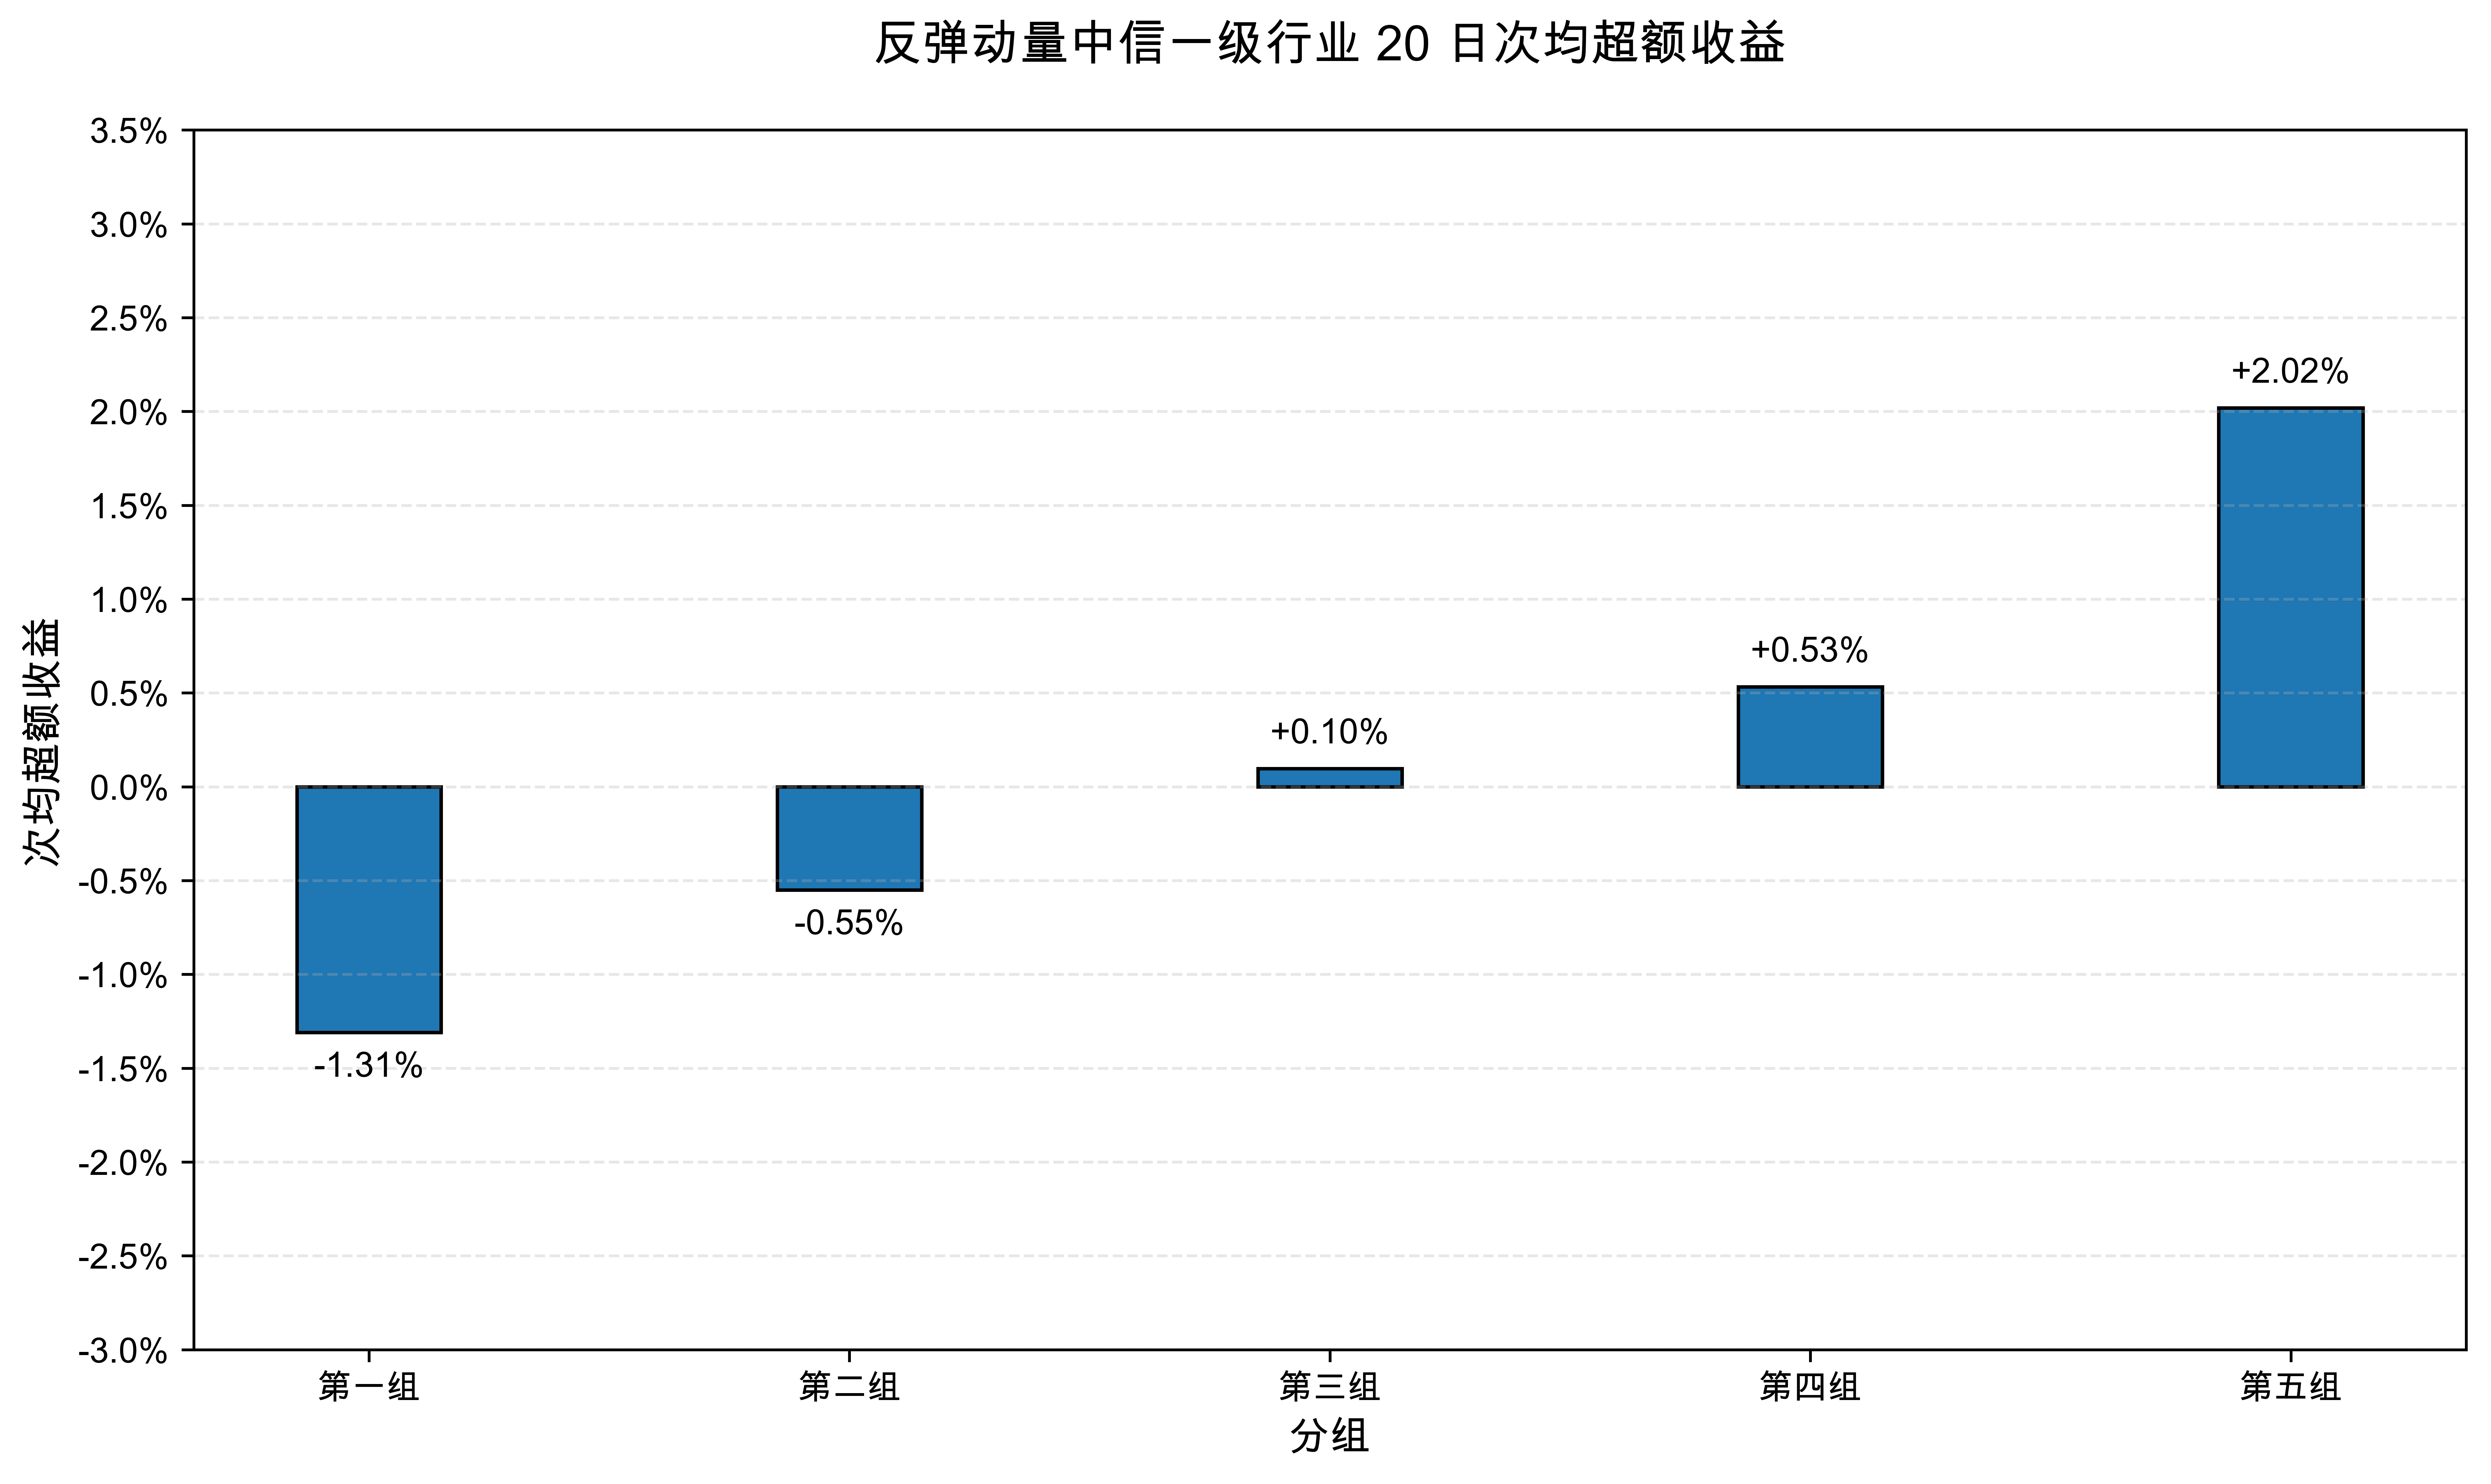

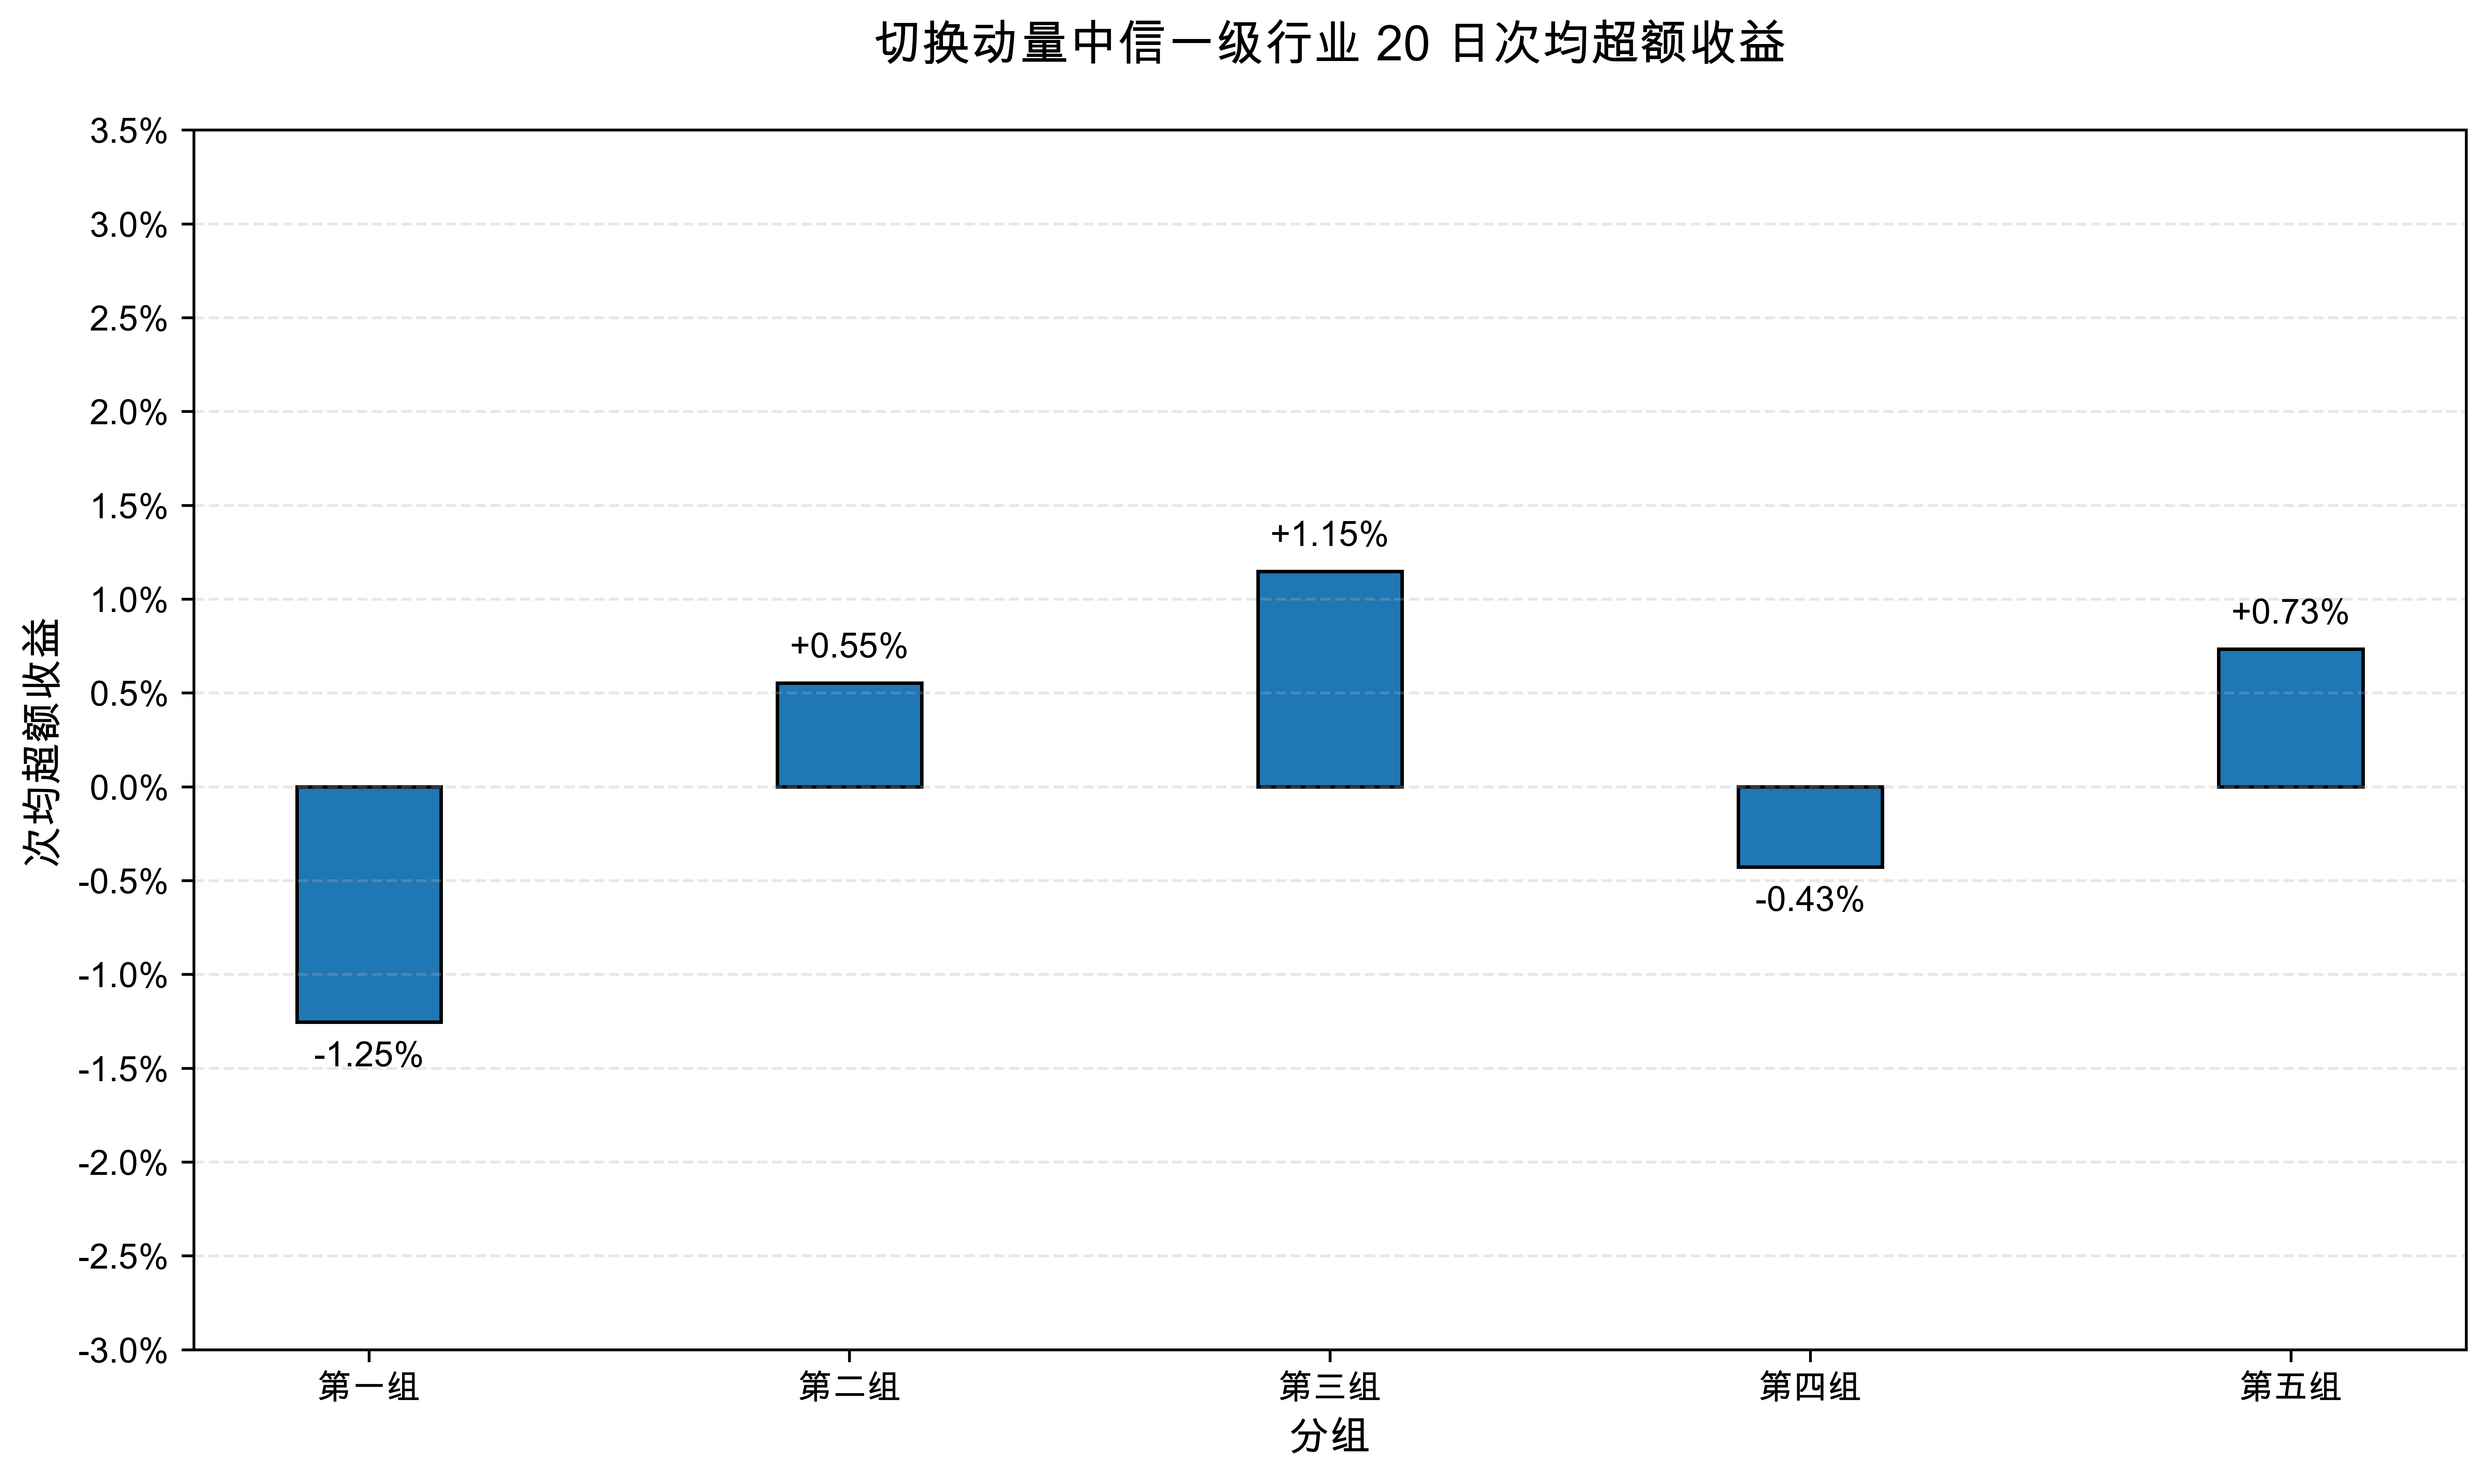

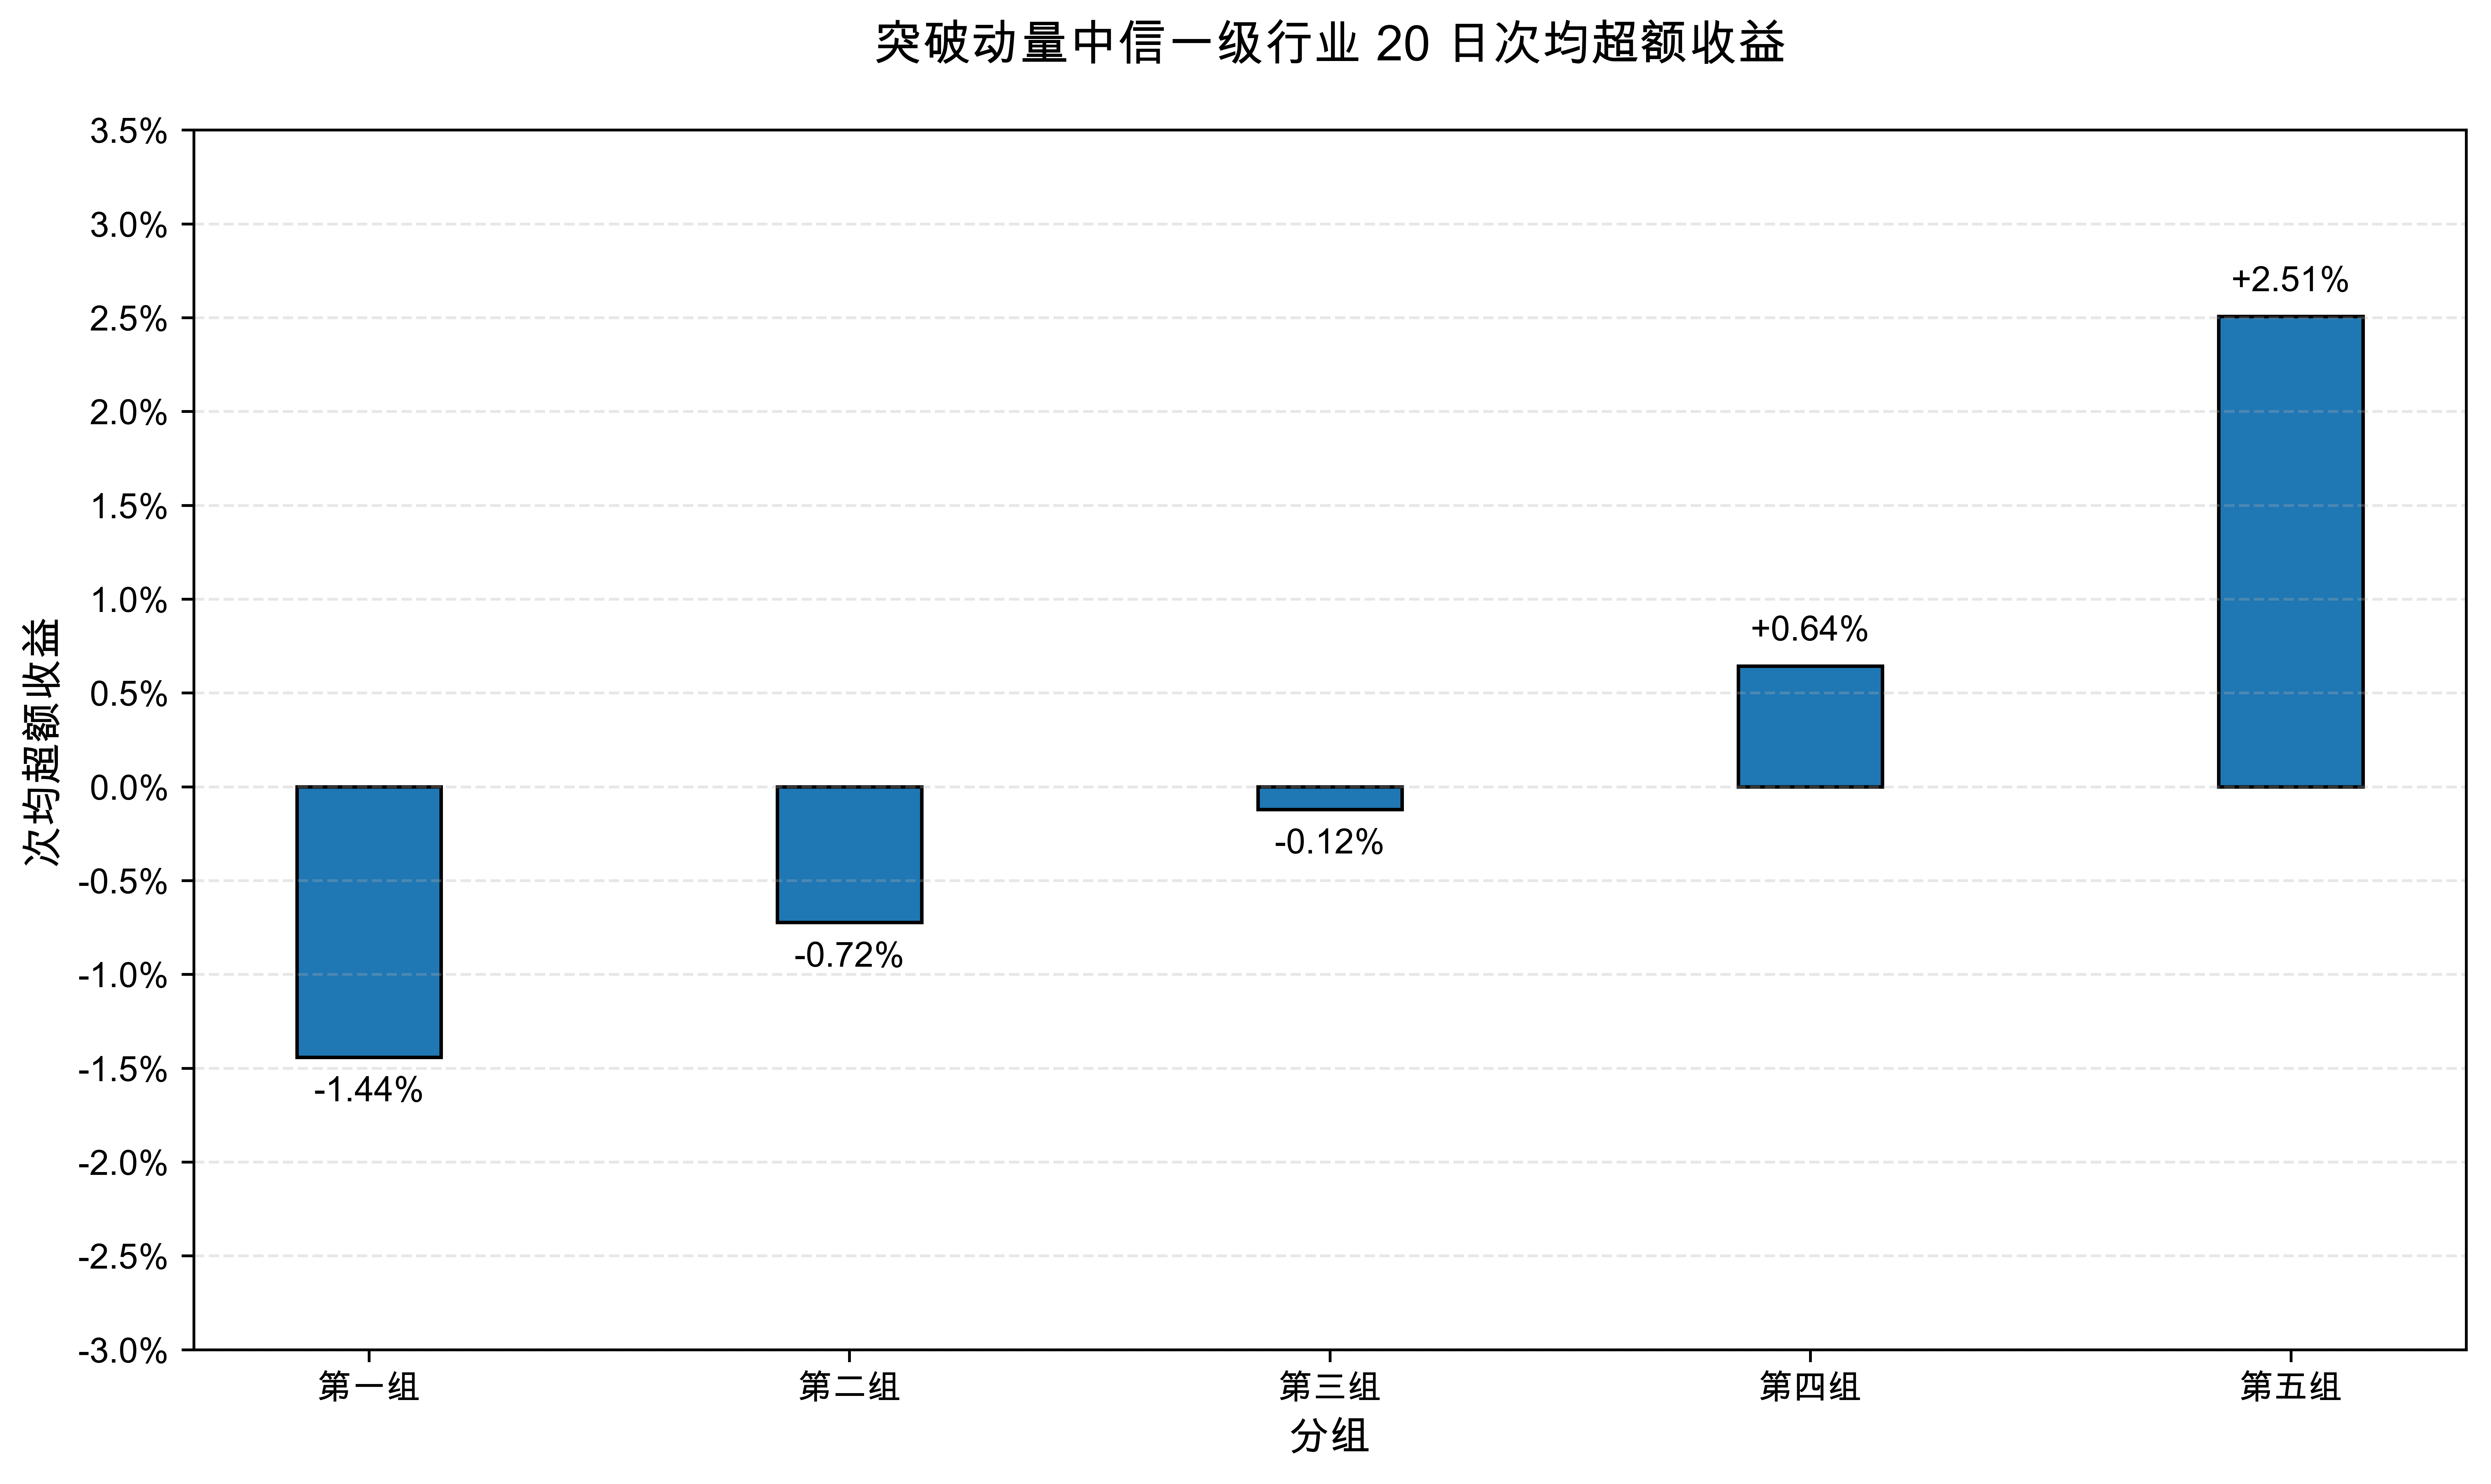

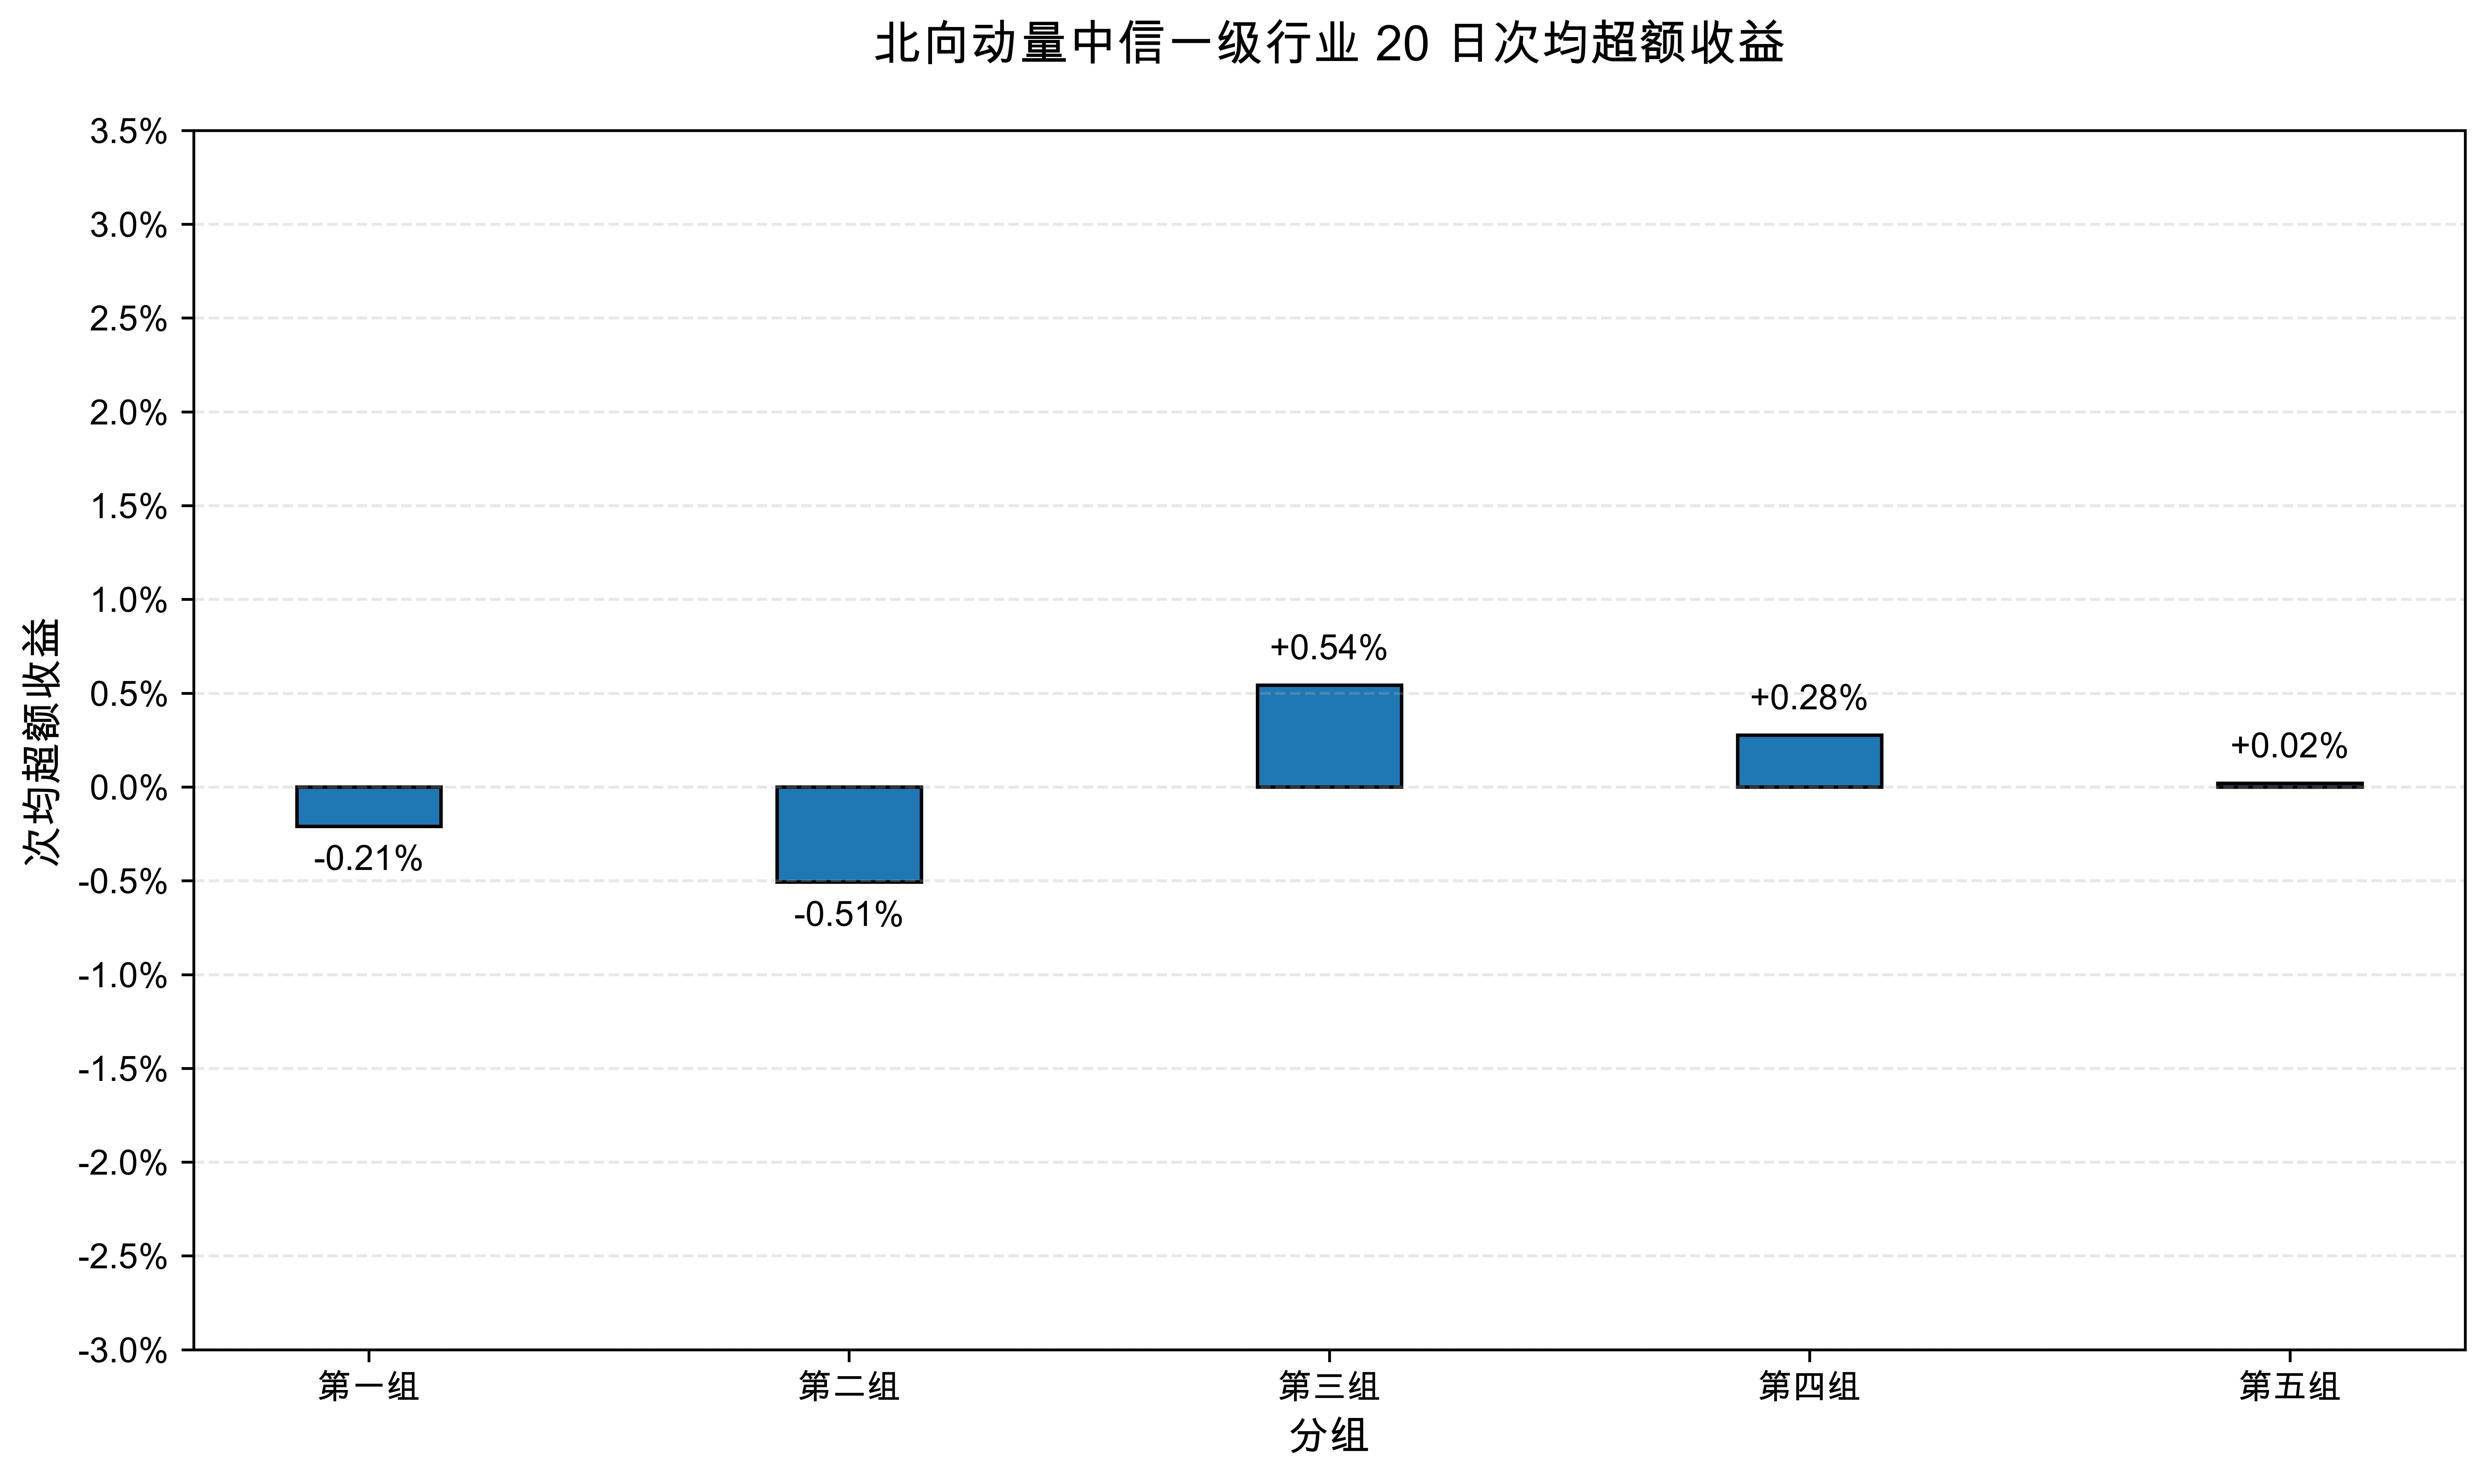

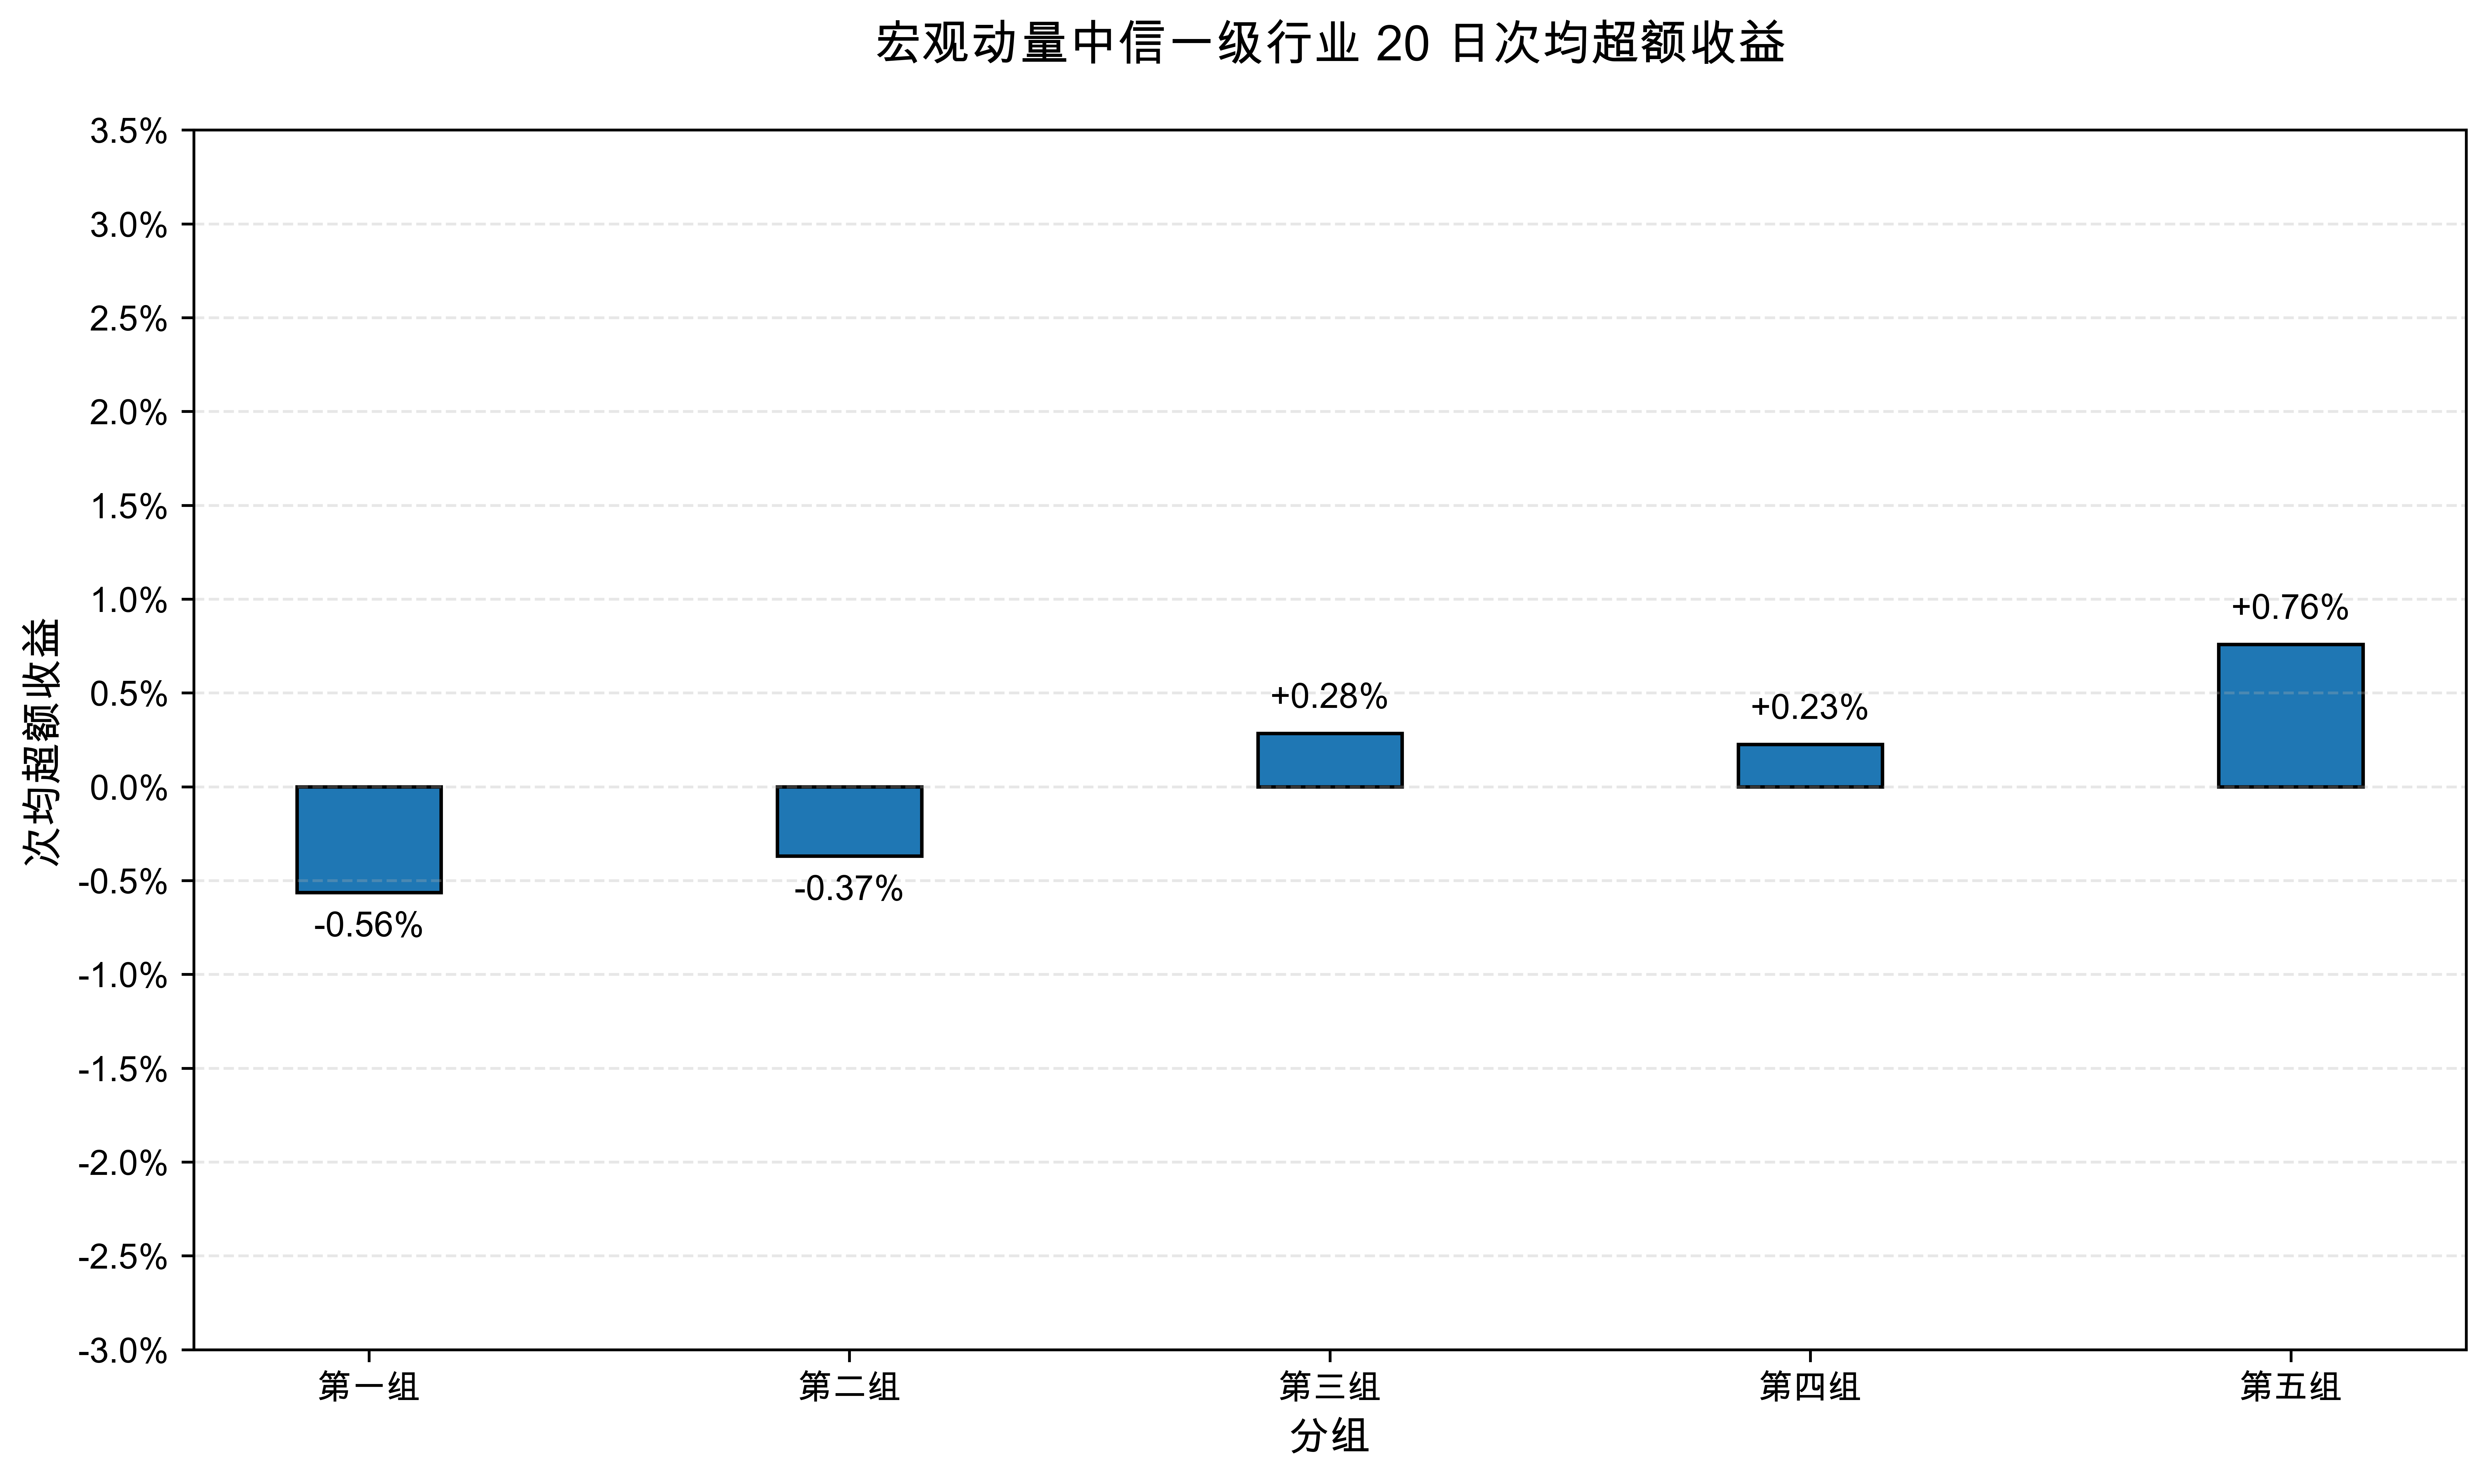

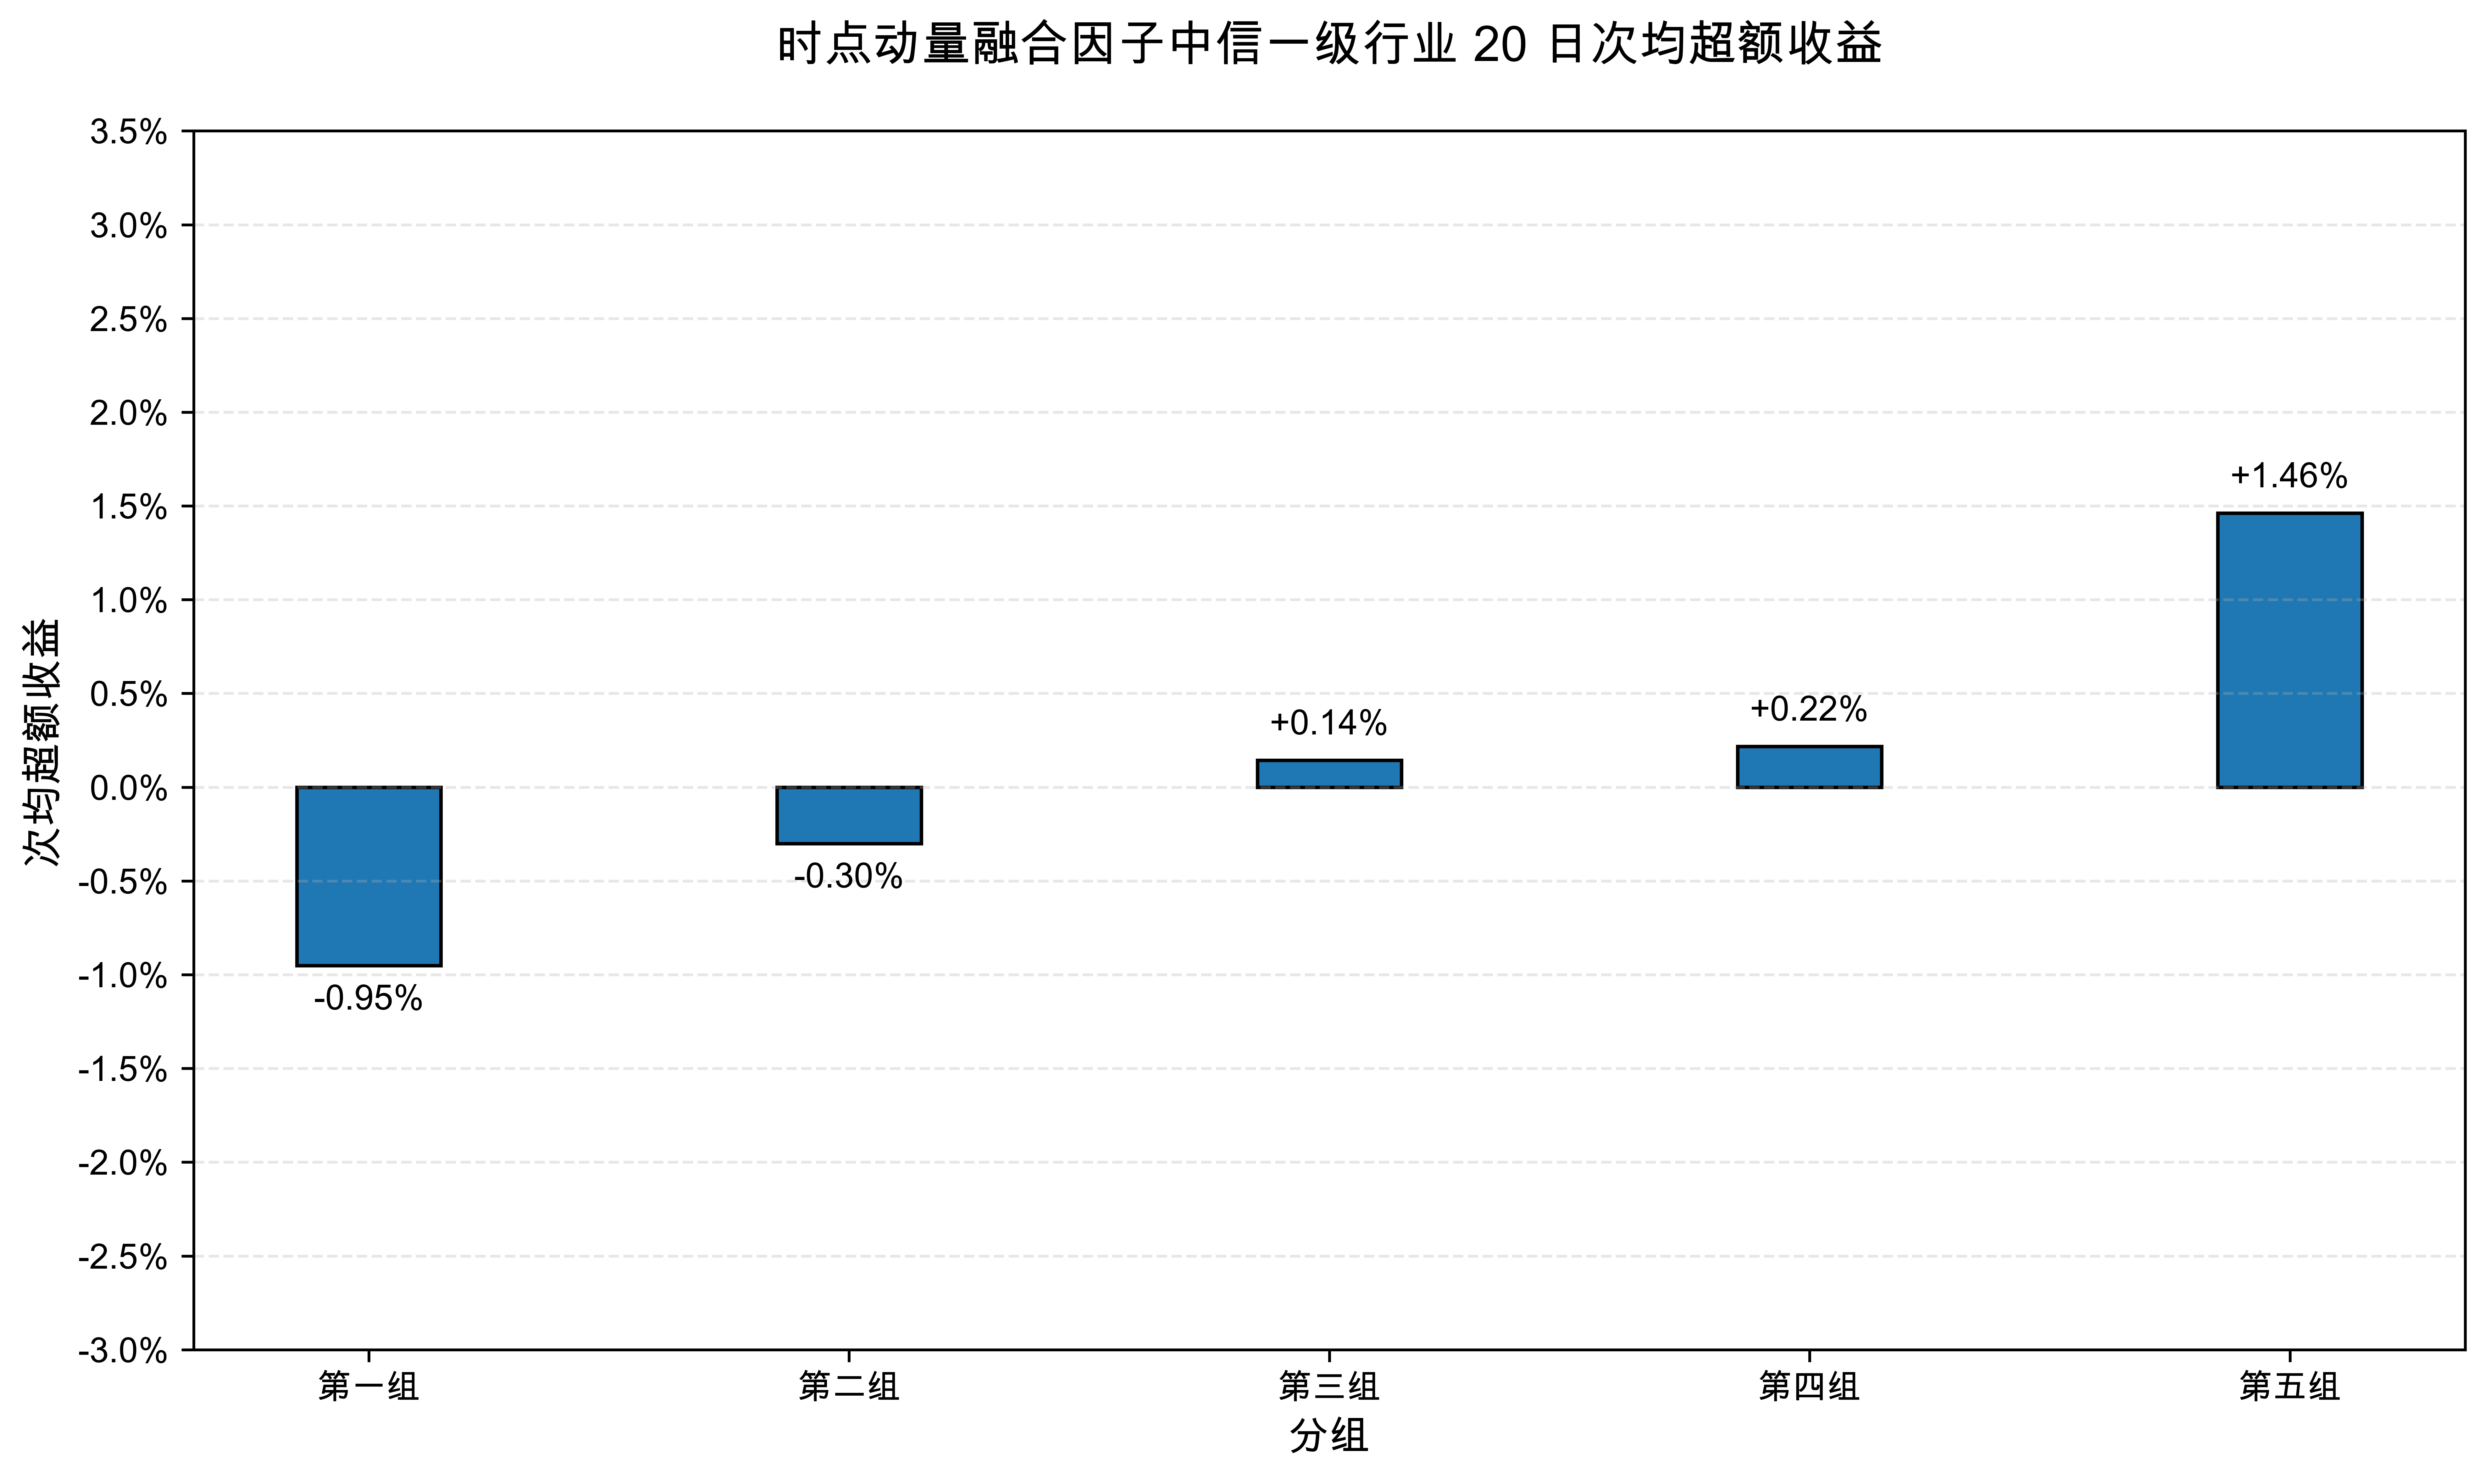

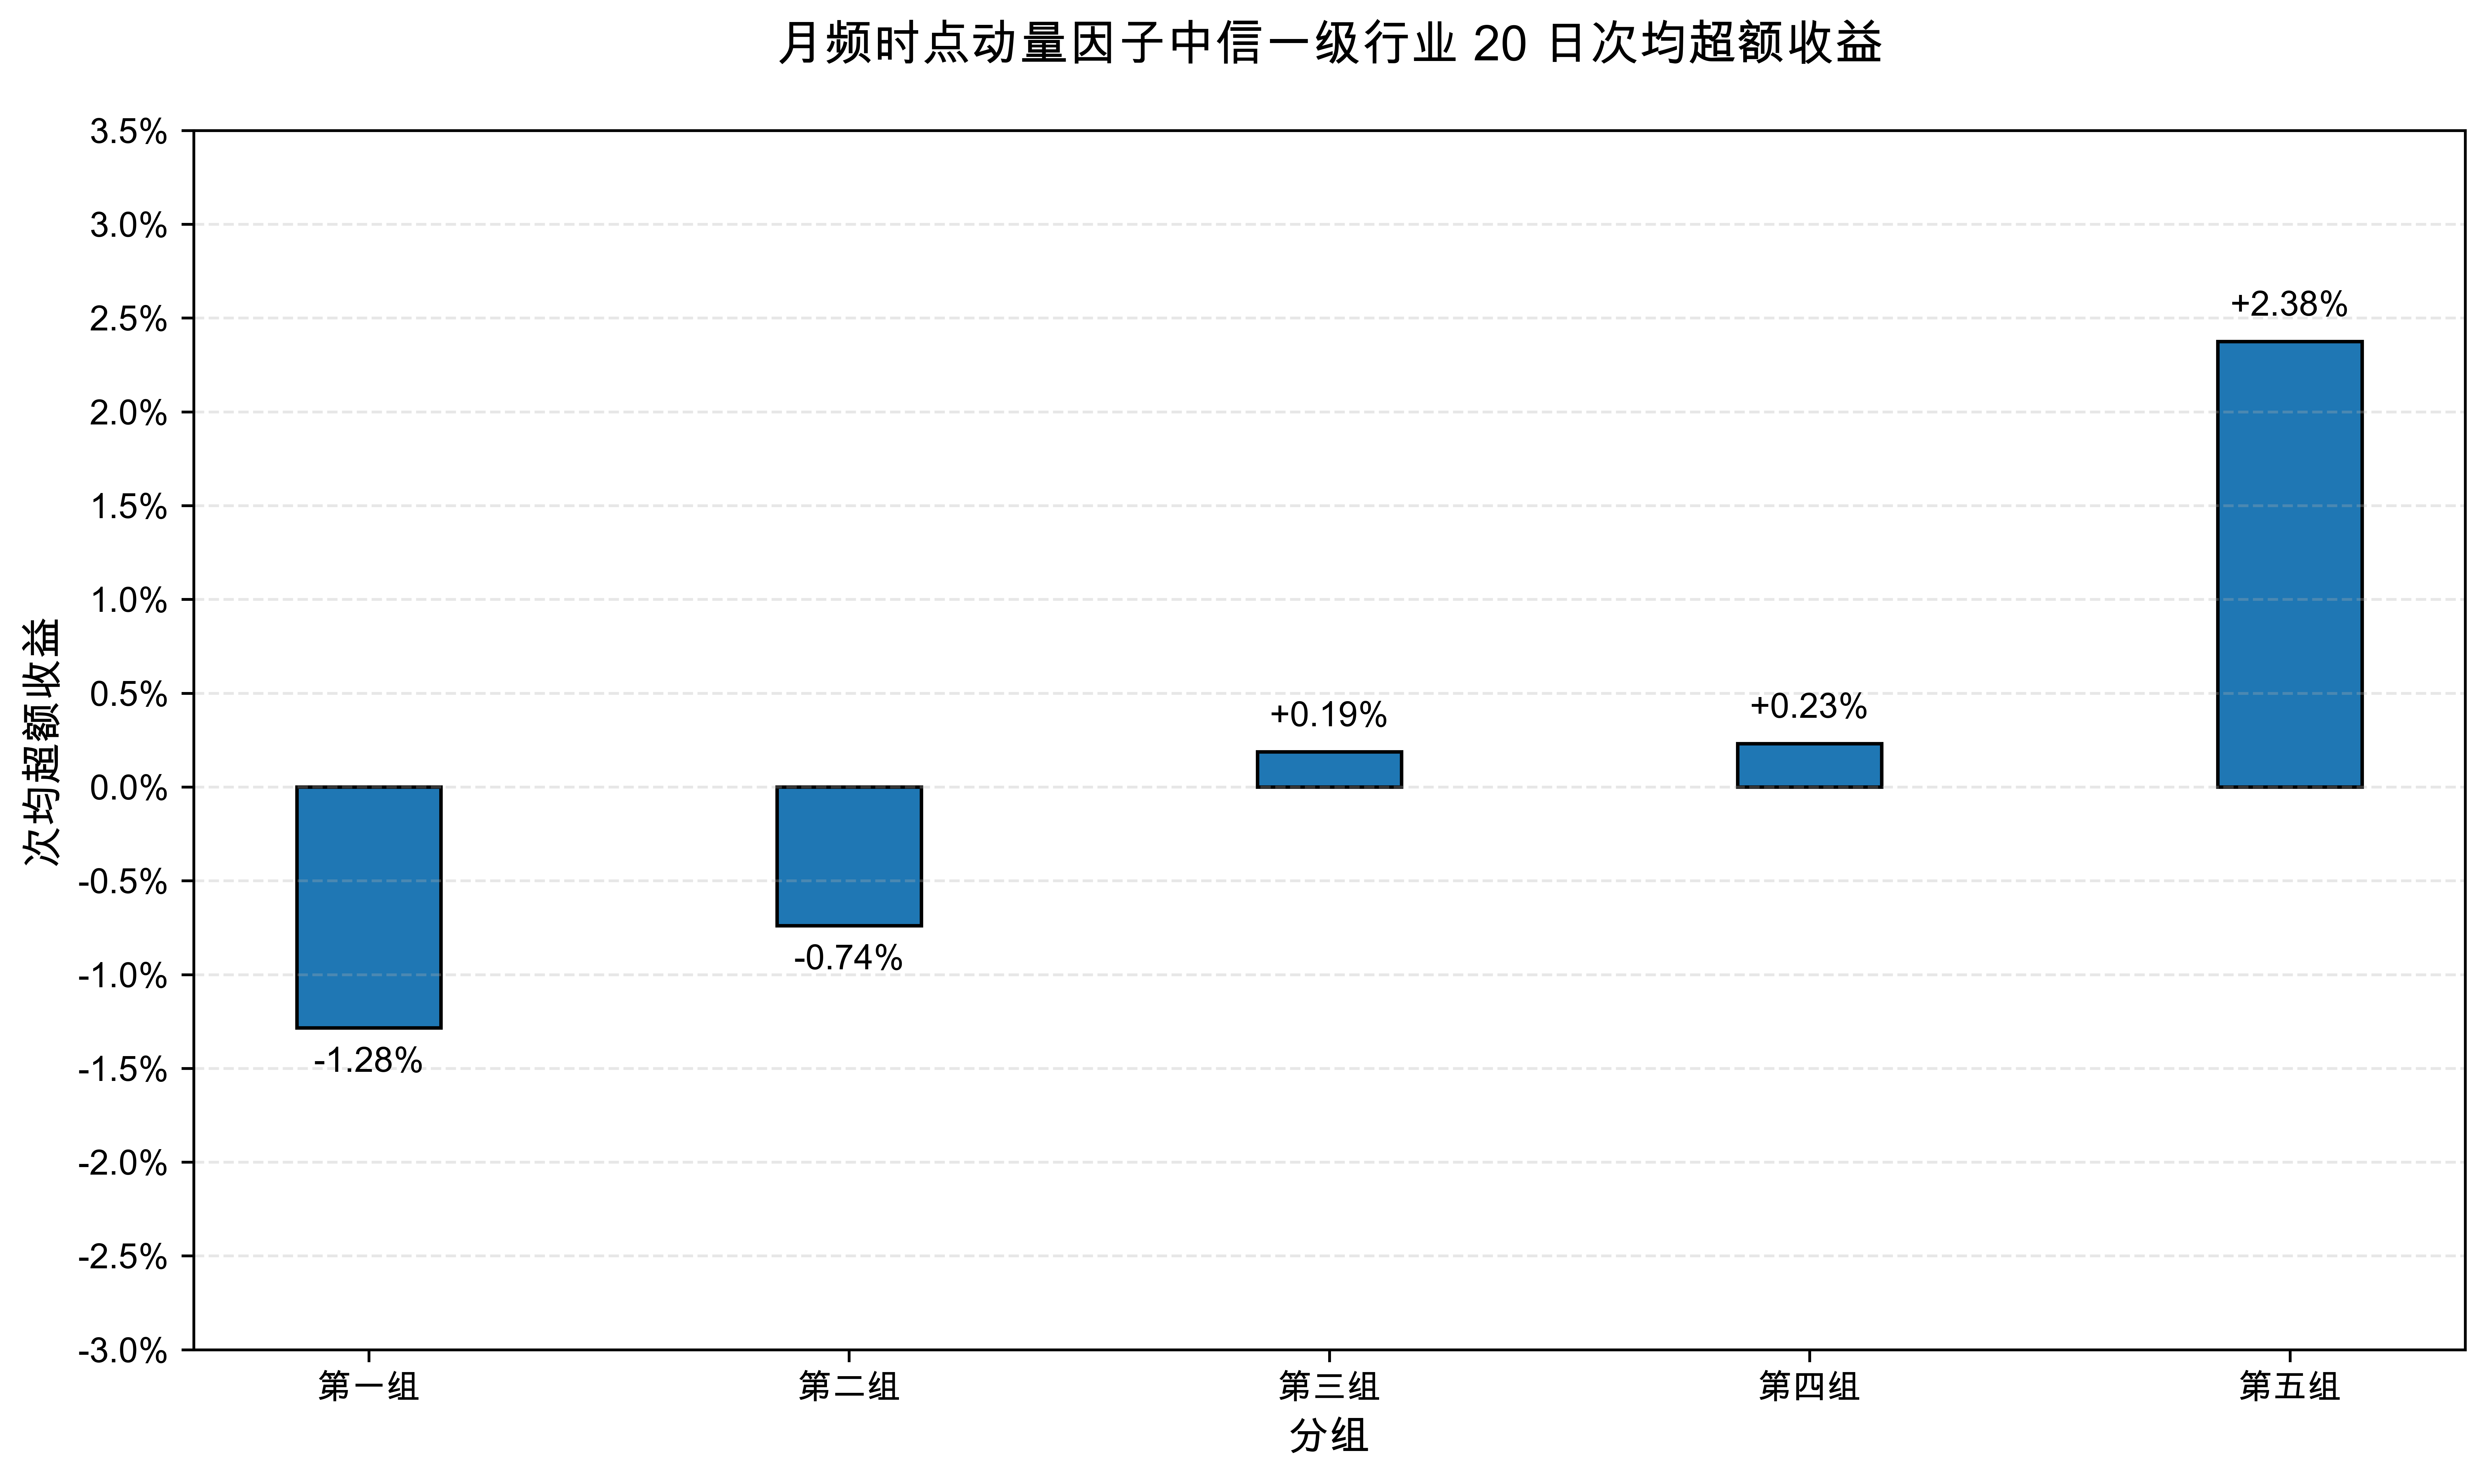

In [55]:
# 可视化各因子分组超额
plot_avg_excess_ret(rebound_avg_excess_ret,'反弹动量')
plot_avg_excess_ret(switch_avg_excess_ret,'切换动量')
plot_avg_excess_ret(breakthrough_avg_excess_ret,'突破动量')
plot_avg_excess_ret(bx_avg_excess_ret,'北向动量')
plot_avg_excess_ret(macro_avg_excess_ret,'宏观动量')
plot_avg_excess_ret(composite_avg_excess_ret,'时点动量融合因子')
plot_avg_excess_ret(composite_monthly_avg_excess_ret,'月频时点动量因子')

# 计算根据因子信号的净值

In [57]:
def cal_net_values(signal):
    """
    函数功能：根据信号通过研报中所采取的计算净值方式来计算累计净值，最终返回多头，空头，以及多空相对净值，同时也会给出每个信号触发日的持仓
    参数：信号
    """
    # 根据研报中所说，每一个信号触发日后以当天收盘价买入持有20日后卖出，
    # 若20日期间出现新的信号，则立刻以当天收盘价卖出后再以当天收盘价买入新的持仓
    # 现在首先直接根据每个信号触发日计算对应的调仓
    result = pd.DataFrame(columns=['信号触发日','持仓到期日','多头净值','空头净值','多空净值','多头累计净值','空头累计净值','多空累计净值'])
    result['信号触发日'] = signal.index
    for i in range(len(result)):
        signal_date = result['信号触发日'][i]
        if inds_price.index.get_loc(signal_date) + 20 < len(inds_price):
            if (i == (len(result) - 1)):
                result['持仓到期日'][i] = inds_price.index[inds_price.index.get_loc(signal_date)+20]
            else:
                result['持仓到期日'][i] = min(inds_price.index[inds_price.index.get_loc(signal_date)+20],result['信号触发日'][i+1])
        else:
            result['持仓到期日'][i] = inds_price.index[-1]
        
    # 计算多头净值：单次及累计
    result['多头净值'] = result.apply(
        lambda x: (inds_price.loc[x['持仓到期日']] / inds_price.loc[x['信号触发日']] - 1)[signal.loc[x['信号触发日']].nlargest(5).index].mean(),
        axis = 1
    )
    result['多头累计净值'] = (result['多头净值'] + 1).cumprod()
    # 计算空头净值：单次及累计
    result['空头净值'] = result.apply(
        lambda x: (inds_price.loc[x['持仓到期日']] / inds_price.loc[x['信号触发日']] - 1)[signal.loc[x['信号触发日']].nsmallest(5).index].mean(),
        axis = 1
    )
    result['空头累计净值'] = (result['空头净值'] + 1).cumprod()
    # 计算多空净值：单次及累计
    result['多空净值'] = (result['多头净值'] - result['空头净值'])
    result['多空累计净值'] = (result['多空净值'] + 1).cumprod()
    
    # 取以下四列赋给result1
    result1 = result[['持仓到期日','多头累计净值','空头累计净值','多空累计净值']]
    # 添加起始行，时间点为2013-01-01
    first_row = pd.DataFrame([[pd.to_datetime('2013-01-01'),1,1,1]],columns=result1.columns)
    result1 = pd.concat([result1,first_row],ignore_index=True)
    result1 = result1.sort_values('持仓到期日')
    result1.set_index('持仓到期日',inplace=True)
    result1.index.name = 'tradt'
    
    # result2用来存储每个信号触发点的多空持仓行业
    result2 = pd.DataFrame({
        '多头持仓': signal.apply(lambda x: x.nlargest(5).index.tolist(), axis=1),
        '空头持仓': signal.apply(lambda x: x.nsmallest(5).index.tolist(), axis=1)
    }, index=signal.index) 
    
    return result1,result2

In [60]:
def plot_net_values(net_value_df,factor_name):
    """
    函数功能：可视化净值图（同时显示多头，空头，多空）
    参数：净值（数据框格式），因子名称（表明是通过哪个因子得到的净值）
    """
    # 自动适配系统字体
    def set_chinese_font():
        system = platform.system()
        if system == 'Darwin':
            return ['Arial Unicode MS']
        elif system == 'Windows':
            return ['SimHei']
        else:
            return ['Noto Sans CJK SC']
    
    mpl.rcParams['font.sans-serif'] = set_chinese_font()
    mpl.rcParams['axes.unicode_minus'] = False

    # 创建画布和主坐标轴
    fig, ax1 = plt.subplots(figsize=(15, 7),dpi=800)
    
    # 绘制左侧Y轴数据（多头和空头净值）
    ax1.plot(net_value_df.index, net_value_df['多头累计净值'], 'b-', linewidth=2, label='多头净值')
    ax1.plot(net_value_df.index, net_value_df['空头累计净值'], 'gray', linestyle='--', linewidth=2, label='空头净值')
    ax1.set_ylabel('净值', fontsize=12)
    ax1.set_ylim(0, 1.2 * net_value_df['多头累计净值'].max())  
    ax1.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))
    
    # 创建右侧Y轴（多空收益累计）
    ax2 = ax1.twinx()
    ax2.plot(net_value_df.index, net_value_df['多空累计净值'], 'r-', linewidth=2, label='多空收益累计(右轴)')
    ax2.set_ylabel('多空收益累计', fontsize=12)
    ax2.set_ylim(0, 1.2 * net_value_df['多空累计净值'].max())  # 匹配图2右侧Y轴范围
    
    # 设置X轴格式
    ax1.xaxis.set_major_locator(plt.MaxNLocator(10))  # 显示约10个日期标签
    fig.autofmt_xdate()  # 自动旋转日期标签
    
    # 添加网格线
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # 合并图例
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    # 设置标题
    plt.title(factor_name+'多空收益累计净值', fontsize=14, pad=20)
    
    # 调整布局
    plt.tight_layout()
    file_path = 'results/效果图/多空累计净值/'+factor_name+'多空收益累计净值.png'
    plt.savefig(file_path,dpi=800,format='png')
    plt.show()

In [62]:
# 计算各因子累计净值，包含多头，空头，多空效果，以及每一期多空持仓行业
rebound_net_values, rebound_pos_inds = cal_net_values(rebound_signals) # 反弹动量
switch_net_values, switch_pos_inds = cal_net_values(switch_signals) # 切换动量
breakthrough_net_values, breakthrough_pos_inds = cal_net_values(breakthrough_signals) # 突破动量
bx_net_values, bx_pos_inds = cal_net_values(bx_signals) # 北向动量
macro_net_values, macro_pos_inds = cal_net_values(macro_signals) # 宏观动量
composite_net_values, composite_pos_inds = cal_net_values(composite_signals) # 时点动量信号 

In [64]:
# 导出各因子累计净值
net_values_to_export = {
    '反弹动量': rebound_net_values,
    '切换动量': switch_net_values,
    '突破动量': breakthrough_net_values,
    '北向动量': bx_net_values,
    '宏观动量': macro_net_values,
    '时点动量融合因子': composite_net_values   
}
export_to_excel(net_values_to_export,'results/各因子多空净值（不含月频融合因子）.xlsx')

# 导出各因子持仓数据
pos_inds_to_export = {
    '反弹动量': rebound_pos_inds,
    '切换动量': switch_pos_inds,
    '突破动量': breakthrough_pos_inds,
    '北向动量': bx_pos_inds,
    '宏观动量': macro_pos_inds,
    '时点动量融合因子': composite_pos_inds     
}
export_to_excel(pos_inds_to_export,'results/持仓详情（不含月频融合因子）.xlsx')

In [66]:
def cal_pos_ind_and_net_value_daily(inds_price,composite_signals):
    # 创建数据框用于计算每次持仓的
    pos_begin_end_dates = pd.DataFrame(columns=['持仓起始日','持仓到期日'])
    pos_begin_end_dates['持仓起始日'] = composite_signals.index
    # 先计算出每个信号触发日对应的持仓到期日
    for i in range(len(pos_begin_end_dates)):
        if i < len(pos_begin_end_dates) - 1:
            if inds_price.index.get_loc(pos_begin_end_dates.loc[i,'持仓起始日']) + 20 < len(inds_price):
                pos_begin_end_dates.loc[i,'持仓到期日'] = min(inds_price.index[inds_price.index.get_loc(pos_begin_end_dates.loc[i,'持仓起始日']) + 20],pos_begin_end_dates.loc[i+1,'持仓起始日'])
            else:
                pos_begin_end_dates.loc[i,'持仓到期日'] = pos_begin_end_dates.loc[i+1,'持仓起始日']
        else:
            if inds_price.index.get_loc(pos_begin_end_dates.iloc[i]['持仓起始日']) + 20 < len(inds_price):
                pos_begin_end_dates.loc[i,'持仓到期日'] = inds_price.index[inds_price.index.get_loc(pos_begin_end_dates.loc[i,'持仓起始日']) + 20]
            else:
                pos_begin_end_dates.loc[i,'持仓到期日'] = inds_price.index[-1]         
    # 接着计算所有空窗期的起始位置
    vacuum_periods = []
    for i in range(len(pos_begin_end_dates)-1):
        if pos_begin_end_dates.loc[i,'持仓到期日'] < pos_begin_end_dates.loc[i+1,'持仓起始日']:
            vacuum_periods.append([pos_begin_end_dates.loc[i,'持仓到期日'],pos_begin_end_dates.loc[i+1,'持仓起始日']])   
    # 合并空窗期
    pos_begin_end_dates = pd.concat([pd.DataFrame(vacuum_periods,columns=pos_begin_end_dates.columns),pos_begin_end_dates],ignore_index=True)
    pos_begin_end_dates = pos_begin_end_dates.sort_values(by='持仓起始日').reset_index(drop=True)
    
    # 计算日频持仓收益情况以及每天的持仓情况
    all_trade_dates = inds_price.loc[pos_begin_end_dates['持仓起始日'].iloc[0]:pos_begin_end_dates['持仓到期日'].iloc[-1]].index
    long_short_ret = pd.DataFrame(index=all_trade_dates,columns=['第1组','第2组','第3组','第4组','第5组'])
    long_short_pos = pd.DataFrame(index=all_trade_dates,columns=['第1组','第2组','第3组','第4组','第5组'])
    
    for i in range(len(pos_begin_end_dates)):
        begin_date = pos_begin_end_dates.loc[i,'持仓起始日']
        end_date = pos_begin_end_dates.loc[i,'持仓到期日']
        # 获取持仓期间所包含的整个交易日区间
        target_dates = inds_price.index[inds_price.index.get_loc(begin_date):inds_price.index.get_loc(end_date)+1].to_list()
        
        # 如果该天有信号触发，筛选出5组持仓行业
        if pos_begin_end_dates.iloc[i].to_list() not in vacuum_periods:
            first_group_inds = composite_signals.loc[begin_date].nlargest(28)[:5].index.tolist() # 第一组5行业
            second_group_inds = composite_signals.loc[begin_date].nlargest(28)[5:11].index.to_list() # 第二组6行业
            third_group_inds = composite_signals.loc[begin_date].nlargest(28)[11:17].index.to_list() # 第三组6行业
            fourth_group_inds = composite_signals.loc[begin_date].nlargest(28)[17:23].index.to_list() # 第四组6行业
            fifth_group_inds = composite_signals.loc[begin_date].nlargest(28)[23:].index.to_list() # 第五组5行业
            # 创建一个列表存储各组行业，方便下面遍历时直接使用
            all_group_inds = [first_group_inds,second_group_inds,third_group_inds,fourth_group_inds,fifth_group_inds]
            # 计算该时间段每组每个交易日的收益以及行业持仓
            for i in range(5):
                long_short_ret.loc[target_dates[1:],f'第{i+1}组'] = inds_price.loc[target_dates,all_group_inds[i]].pct_change().dropna().mean(axis=1)
                long_short_pos.loc[target_dates[1:],f'第{i+1}组'] = long_short_pos.loc[target_dates[1:],f'第{i+1}组'].apply(lambda x: all_group_inds[i])
    
        # 如果当天没有信号触发，则每组都是全行业等权持仓
        else:
            # 计算该时间段每组每个交易日的收益以及行业持仓
            for i in range(5):
                long_short_ret.loc[target_dates[1:],f'第{i+1}组'] = inds_price.loc[target_dates].pct_change().dropna().mean(axis=1)
                long_short_pos.loc[target_dates[1:],f'第{i+1}组'] = '等权'
    # 因为是以当天收盘价买入，所以第一天的收益率是0，同时第一天还没有持仓行业
    long_short_ret.fillna(0,inplace=True)
    long_short_pos.dropna(inplace=True) 
    
    # 将单次收益转化为累计收益
    long_short_ret = (long_short_ret + 1).cumprod()

    # 为后续方便计算指标，新增一个等权持仓列
    long_short_ret['等权'] = inds_price.loc[long_short_ret.index].pct_change().mean(axis=1).fillna(0)
    long_short_ret['等权'] = (long_short_ret['等权'] + 1).cumprod()
    return long_short_pos, long_short_ret

In [68]:
daily_pos_5_group,daily_ret_5_group = cal_pos_ind_and_net_value_daily(inds_price,composite_signals)

In [69]:
def plot_net_value_daily(df):
    """
    此函数用于可视化时点动量融合因子日频满仓累计净值
    """
    # 假设您的数据框名为 df，且日期已经是索引
    plt.figure(figsize=(12, 8),dpi=800)
    
    # 绘制三条曲线
    plt.plot(df.index, df['第1组'], label='多头（第1组）', linewidth=2, color='red')
    plt.plot(df.index, df['第5组'], label='空头（第5组）', linewidth=2, color='blue')
    plt.plot(df.index, df['等权'], label='等权组合', linewidth=2, color='green')
    
    # 设置图表标题和标签
    plt.title('多头、空头和等权累计净值走势图', fontsize=16, fontweight='bold')
    plt.xlabel('日期', fontsize=12)
    plt.ylabel('累计净值', fontsize=12)
    
    # 设置图例
    plt.legend(fontsize=12)
    
    # 优化横坐标日期显示
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gcf().autofmt_xdate()  # 自动旋转日期标签
    
    # 添加网格
    plt.grid(True, alpha=0.3)
    
    # 显示图表
    plt.tight_layout()
    file_path = 'results/效果图/多空累计净值/时点动量融合因子日频满仓多空收益累计净值.png'
    plt.savefig(file_path,dpi=800,format='png')
    plt.show()

In [72]:
def evaluate_long_short_effect_daily(daily_ret_5_group):
    """
    此函数用于计算数据包含所有年份的历年以来多空效果，会计算
    ['年化收益', '年化波动', '最大回撤', '年化超额', '超额最大回撤', '调仓胜率']这些指标
    最终返回一个双层行索引数据框，该数据框列是指标名称，外层行索引是年份，内层行索引是['多头','空头','等权']
    """
    year_groups = daily_ret_5_group.groupby(daily_ret_5_group.index.year)
    # 第一个年份初始日期净值为1，所以不需要处理；但从第二个年份开始，第一行需补充为上一年最后一个交易日净值数据
    years = sorted(year_groups.groups.keys())
    modified_yearly_data_lst = []
    for i, year in enumerate(years):
        current_year_data = year_groups.get_group(year)
        if i == 0:
            modified_yearly_data_lst.append(current_year_data)
        else:
            # 获取上一年的最后一行
            previous_year_last_row = year_groups.get_group(years[i-1]).iloc[[-1]]
            current_year_modified = pd.concat([previous_year_last_row,current_year_data])
            modified_yearly_data_lst.append(current_year_modified)
    
    # 将结果存储为字典
    year_group_dict = dict(zip(years,modified_yearly_data_lst))
    # 再新增一个全回测期
    year_group_dict['全回测期'] = daily_ret_5_group
    
    all_periods = years + ['全回测期']
    
    # 创建一个空的储存指标计算结果的数据框
    # 使用双层行索引
    multi_index = pd.MultiIndex.from_product(
        [all_periods,['多头','空头','等权']],
        names = ['年份','策略']
    )
    evaluate_results = pd.DataFrame(index=multi_index,columns=['年化收益','年化波动','夏普比率','最大回撤','年化超额','超额最大回撤','调仓胜率'])
    
    # 循环计算每年相应指标
    for year in all_periods:
        net_value_data = year_group_dict[year] 
        
        # 计算各策略指标
        results = {}
        strategies = {
            '多头': net_value_data['第1组'],
            '空头': net_value_data['第5组'],
            '等权': net_value_data['等权']
        }
        for strategy_name, net_value in strategies.items():
            # 日收益率
            daily_returns = net_value.pct_change().dropna()
        
            # 年化收益
            total_return = net_value.iloc[-1] / net_value.iloc[0] - 1
            holding_days = len(daily_returns)
            annual_return = (1 + total_return) ** (252 / holding_days) - 1
        
            # 年化波动
            annual_volatility = daily_returns.std() * np.sqrt(252)
        
            # 夏普比率
            excess_returns = daily_returns - (0.015/252)
            sharpe_ratio = np.sqrt(252) * excess_returns.mean() / excess_returns.std()
        
            # 最大回撤
            cumulative_max = net_value[1:].cummax()
            drawdown = (net_value[1:] - cumulative_max) / cumulative_max
            max_drawdown = drawdown.min()
        
            # 年化超额（几何法）
            if strategy_name != '等权':
                total_benchmark_return = net_value_data['等权'].iloc[-1] / net_value_data['等权'].iloc[0] - 1
                total_excess_return = (1 + total_return) / (1 + total_benchmark_return) - 1
                annual_excess_return = (1 + total_excess_return) ** (252 / holding_days) - 1
            else:
                annual_excess_return = np.nan
        
            # 超额最大回撤
            if strategy_name != '等权':
                strategy_excess = net_value / net_value_data['等权']
                excess_cummax = strategy_excess.cummax()
                excess_drawdown = (strategy_excess - excess_cummax) / excess_cummax
                excess_max_drawdown = excess_drawdown.min()
            else:
                excess_max_drawdown = np.nan
        
            # 调仓胜率
            win_rate = (daily_returns > 0).mean()
        
            # 存储结果
            results[strategy_name] = {
                '年化收益': annual_return,
                '年化波动': annual_volatility,
                '夏普比率': sharpe_ratio,
                '最大回撤': max_drawdown,
                '年化超额': annual_excess_return,
                '超额最大回撤': excess_max_drawdown,
                '调仓胜率': win_rate
            }
    
        evaluate_results.loc[(year, '多头'), :] = results['多头']
        evaluate_results.loc[(year, '空头'), :] = results['空头']
        evaluate_results.loc[(year, '等权'), :] = results['等权']
        
    percent_cols = ['年化收益', '年化波动', '最大回撤', '年化超额', '超额最大回撤', '调仓胜率']
    evaluate_results[percent_cols] = evaluate_results[percent_cols].applymap(
        lambda x: f"{x:.2%}" if not pd.isna(x) else np.nan
    )
    evaluate_results['夏普比率'] = evaluate_results['夏普比率'].apply(
        lambda x: f"{x:.2f}" if not pd.isna(x) else np.nan
    )

    return evaluate_results

In [74]:
evaluate_results = evaluate_long_short_effect_daily(daily_ret_5_group)

In [76]:
evaluate_results

年化收益    年化波动   夏普比率     最大回撤     年化超额   超额最大回撤    调仓胜率
年份   策略                                                           
2013 多头   25.33%  25.09%   0.97  -13.61%   18.67%   -6.63%  54.76%
     空头  -10.51%  25.52%  -0.37  -24.50%  -15.27%  -15.96%  53.33%
     等权    5.61%  22.12%   0.29  -16.45%      NaN      NaN  54.76%
2014 多头   95.12%  22.19%   3.06   -9.19%   31.57%   -3.70%  58.78%
     空头   27.15%  19.52%   1.25  -13.42%  -14.26%  -16.37%  56.73%
     等权   48.30%  18.87%   2.10  -11.35%      NaN      NaN  58.78%
2015 多头  114.49%  52.12%   1.70  -42.37%   41.52%   -6.00%  61.89%
     空头   13.10%  46.90%   0.47  -56.85%  -25.38%  -27.87%  61.07%
     等权   51.56%  50.34%   1.05  -51.52%      NaN      NaN  61.07%
2016 多头   -9.38%  33.32%  -0.17  -24.58%    4.81%   -6.34%  52.87%
     空头  -12.66%  26.16%  -0.44  -20.53%    1.02%   -8.03%  52.05%
     等权  -13.55%  30.38%  -0.37  -25.58%      NaN      NaN  52.87%
2017 多头    4.38%  13.56%   0.27  -13.12%    2.75%   -4.59%  53.28%
     空头    1.44%  12.91%   0.06   -9.98%   -0.15%   -6.64%  54.51%
     等权    1.58%  12.18%   0.07  -10.91%      NaN      NaN  56.97%
2018 多头  -22.60%  22.81%  -1.07  -30.28%    9.52%   -6.31%  47.74%
     空头  -41.47%  23.11%  -2.26  -43.08%  -17.19%  -18.26%  44.86%
     等权  -29.33%  21.76%  -1.55  -33.25%      NaN      NaN  47.74%
2019 多头   52.66%  22.45%   1.93  -13.45%   17.49%   -3.37%  57.38%
     空头   20.52%  20.40%   0.94  -18.11%   -7.25%  -10.31%  56.15%
     等权   29.93%  20.65%   1.30  -16.88%      NaN      NaN  54.51%
2020 多头   55.08%  24.48%   1.86  -13.51%   25.00%   -4.66%  56.38%
     空头    7.29%  26.60%   0.34  -19.52%  -13.52%  -14.95%  50.21%
     等权   24.06%  22.96%   0.99  -14.23%      NaN      NaN  55.14%
2021 多头   33.09%  20.33%   1.43  -11.50%   18.34%   -6.19%  59.26%
     空头   -0.69%  15.68%  -0.06  -10.29%  -11.69%  -12.17%  53.09%
     等权   12.46%  15.23%   0.75   -8.47%      NaN      NaN  55.97%
2022 多头   -4.38%  22.22%  -0.16  -25.79%   11.59%   -4.49%  52.07%
     空头  -19.73%  20.50%  -1.04  -23.13%   -6.32%  -11.71%  48.76%
     等权  -14.32%  20.34%  -0.73  -24.24%      NaN      NaN  50.00%
2023 多头    9.96%  15.27%   0.60  -13.98%   14.96%   -6.19%  53.31%
     空头  -13.07%  14.28%  -1.01  -20.90%   -9.11%  -11.51%  46.69%
     等权   -4.35%  12.65%  -0.41  -14.78%      NaN      NaN  47.93%
2024 多头   10.11%  28.26%   0.43  -20.97%    0.62%   -5.98%  47.93%
     空头    2.52%  22.56%   0.16  -18.72%   -6.31%  -11.03%  50.41%
     等权    9.42%  25.00%   0.42  -17.66%      NaN      NaN  50.00%
2025 多头   37.25%  23.03%   1.43  -13.11%   16.89%   -7.87%  56.43%
     空头  -13.56%  18.44%  -0.78  -16.18%  -26.38%  -16.06%  53.57%
     等权   17.42%  18.12%   0.90  -12.59%      NaN      NaN  57.14%
全回测期 多头   25.22%  26.80%   0.92  -42.37%   15.89%   -7.87%  54.73%
     空头   -4.35%  24.10%  -0.13  -77.35%  -11.48%  -76.99%  52.38%
     等权    8.05%  24.45%   0.38  -58.09%      NaN      NaN  53.97%

In [78]:
# 导出时点动量融合因子日频调仓结果
composite_values_to_export = {
    '持仓详情': daily_pos_5_group,
    '累计净值': daily_ret_5_group,
    '评价指标': evaluate_results,
}
export_to_excel(composite_values_to_export,'results/时点动量融合因子行业测试效果日频满仓.xlsx')

In [80]:
def cal_monthly_net_value(signal):
    """
    此函数专为最终得到的月频信号因子设计，用于计算月频因子累计净值，同时给出每个信号触发日的持仓
    """
    # 由于月频时点动量因子是统一月频调仓，其回测方式需专门写一个
    net_value_monthly = pd.DataFrame(index=signal.index,columns=['多头累计净值','空头累计净值','多空累计净值'])
    net_value_monthly.iloc[0] = [0,0,0]
    # 首先求出各时间点单次收益
    for i in range(len(signal)-1):
        # 如果该月底没有信号则等权持有全市场行业（不包含综合、综合金融）
        if signal.iloc[i].isna().all():
            net_value_monthly.iloc[i+1]['多头累计净值'] = (inds_price.loc[signal.index[i+1]] / inds_price.loc[signal.index[i]] - 1).mean()
            net_value_monthly.iloc[i+1]['空头累计净值'] = net_value_monthly.iloc[i+1]['多头累计净值']
            net_value_monthly.iloc[i+1]['多空累计净值'] = 0
        else:
            net_value_monthly.iloc[i+1]['多头累计净值'] = (inds_price.loc[signal.index[i+1]] / inds_price.loc[signal.index[i]] - 1)[composite_monthly_signals.iloc[i].nlargest(5).index].mean()
            net_value_monthly.iloc[i+1]['空头累计净值'] = (inds_price.loc[signal.index[i+1]] / inds_price.loc[signal.index[i]] - 1)[composite_monthly_signals.iloc[i].nsmallest(5).index].mean()
            net_value_monthly.iloc[i+1]['多空累计净值'] = net_value_monthly.iloc[i+1]['多头累计净值'] - net_value_monthly.iloc[i+1]['空头累计净值']
    # 得到各时间点单次收益后，再计算累计收益
    net_value_monthly = net_value_monthly.apply(lambda x: (x+1).cumprod())

    # 接下来是计算每个信号触发日的多头空头持仓行业
    pos_inds = pd.DataFrame(index = signal.index,columns=['多头持仓','空头持仓'])
    for i in range(len(signal)):
        if ~signal.iloc[i].isna().all():
            pos_inds.iloc[i]['多头持仓'] = signal.iloc[i].nlargest(5).index.to_list()
            pos_inds.iloc[i]['空头持仓'] = signal.iloc[i].nsmallest(5).index.to_list()
    return net_value_monthly, pos_inds

In [82]:
# 月频信号累计净值及持仓数据
composite_monthly_net_values, composite_monthly_pos_inds = cal_monthly_net_value(composite_monthly_signals)

# 导出月频因子累计净值以及持仓
info_to_export = {
    '持仓详情':composite_monthly_pos_inds,
    '累计净值':composite_monthly_net_values
}
export_to_excel(info_to_export,'results/月频时点动量测试结果.xlsx')

In [84]:
composite_monthly_net_values

,多头累计净值,空头累计净值,多空累计净值
tradt,,,
2013-01-31,1,1,1
2013-02-28,1.023255,1.023255,1
2013-03-29,0.998333,0.935542,1.061365
2013-04-26,0.995973,0.938408,1.055604
2013-05-31,1.116051,1.035289,1.07389
...,...,...,...
2025-03-31,8.723498,0.909602,9.046183
2025-04-30,8.505244,0.886845,9.046183
2025-05-30,8.666673,0.913084,8.950226


In [86]:
# 可视化各因子累计净值
plot_net_values(composite_net_values,'时点动量信号')